# COSC2671 Social Media and Network Analytics
## Assignment 2 – User Perceptions of Apple and Samsung Ecosystems

## Authors:
### Ngoc Anh Thu Nguyen (s3912314) 
### Ritik Kadwane (s4068947)


# Load all the needed library

In [3]:
import json
from pathlib import Path
import pandas as pd
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
import scipy, decorator

# 1. Introduction

Apple and Samsung are two of the most compared smartphone brands in online communities. This project investigates user perceptions of both brands and their associated operating systems, iOS and Android, across Reddit and YouTube. Understanding how consumers discuss these brands on social media reveals not just what people think about the devices themselves but how they feel about the broader ecosystems they have chosen to be part of.

Discussions across both platforms frequently covered hardware comparisons, software experience, ecosystem integration, customisation, and switching decisions between the two platforms. By combining sentiment analysis, topic modelling, and social network analysis, we aimed to capture both what users say and how they interact with each other when discussing these two competing ecosystems.

## Research Questions

We address three research questions:

- RQ1: How does sentiment differ between Samsung and iPhone communities, and is any observed difference meaningful?

- RQ2: What topics dominate Samsung/Android and iPhone/iOS communities, and how do users describe their experiences with each ecosystem?

- RQ3: How do network structure and information diffusion differ between Reddit and YouTube as discussion platforms?

## Project Objectives

The project aims to:

1. Compare sentiment between Samsung and iPhone discussions across both platforms

2. Identify the main discussion topics within each brand community

3. Examine how interaction structures differ between Reddit and YouTube

4. Explore how discussion behaviour and interaction patterns differ across platforms and brand communities

We analyse approximately 50,000 public comments from Reddit and YouTube using sentiment analysis, topic modelling, and social network analysis techniques. Statistical testing was used to examine whether observed sentiment differences between communities were meaningful.

## What Success Looks Like

We consider the analysis successful if we can show measurable sentiment differences between brand communities with statistical evidence, identify at least five distinct topics per brand that reflect genuine community focus areas, construct reply networks that reveal structural differences between Reddit and YouTube, link detected communities back to NLP findings, and compare information diffusion behaviour across both platforms.


# 2. Data Collection

To start, we loaded the Reddit and YouTube data we had already collected. Both datasets were saved as JSON files, so we read them in, checked the basic collection information, and verified the structure before moving on to analysis.

In [7]:
# Set the file paths for the two JSON files
reddit_json_path = Path("reddit_data.json")
youtube_json_path = Path("youtube_data.json")

# Open and read the Reddit JSON file
with open(reddit_json_path, "r", encoding="utf-8") as reddit_file:
    reddit_raw = json.load(reddit_file)

# Open and read the YouTube JSON file
with open(youtube_json_path, "r", encoding="utf-8") as youtube_file:
    youtube_raw = json.load(youtube_file)

# Check the data type of each loaded JSON file
print("Reddit data type:", type(reddit_raw))
print("YouTube data type:", type(youtube_raw))

Reddit data type: <class 'dict'>
YouTube data type: <class 'dict'>


In [8]:
# Print some basic information about the Reddit data collection
print("Reddit platform:", reddit_raw["platform"])
print("Reddit source:", reddit_raw["source"])
print("Reddit collected at:", reddit_raw["collectedAt"])
print("Total Reddit posts:", reddit_raw["totalPosts"])
print("Total Reddit comments:", reddit_raw["totalComments"])

print()

# Print some basic information about the YouTube data collection
print("YouTube platform:", youtube_raw["platform"])
print("YouTube source:", youtube_raw["source"])
print("YouTube collected at:", youtube_raw["collectedAt"])
print("Total YouTube videos:", youtube_raw["totalVideos"])
print("Total YouTube comments:", youtube_raw["totalComments"])

Reddit platform: reddit
Reddit source: Arctic Shift API
Reddit collected at: 2026-05-21T12:04:24Z
Total Reddit posts: 42
Total Reddit comments: 11610

YouTube platform: youtube
YouTube source: YouTube Data API v3
YouTube collected at: 2026-05-21T12:19:56Z
Total YouTube videos: 3
Total YouTube comments: 40910


In [9]:
# Store the actual Reddit posts and YouTube videos in separate variables
reddit_posts_list = reddit_raw["posts"]
youtube_videos_list = youtube_raw["videos"]

# Check how many main records are inside each dataset
print("Number of Reddit posts:", len(reddit_posts_list))
print("Number of YouTube videos:", len(youtube_videos_list))

Number of Reddit posts: 42
Number of YouTube videos: 3


In [10]:
# Convert the Reddit posts and YouTube videos into pandas tables
reddit_posts_table = pd.DataFrame(reddit_posts_list)
youtube_videos_table = pd.DataFrame(youtube_videos_list)

# Also checking the number of rows and columns in each table
print("Reddit posts table shape:", reddit_posts_table.shape)
print("YouTube videos table shape:", youtube_videos_table.shape)

Reddit posts table shape: (42, 9)
YouTube videos table shape: (3, 13)


In [11]:
# Show the first few rows to see how the data looks in table format
display(reddit_posts_table.head())
display(youtube_videos_table.head())

,title,postId,subreddit,author,publishedAt,score,numComments,url,comments
0,Iphones are so overrated...,1l0i3nb,Smartphones,VideoAffectionate977,2025-06-01T06:21:01Z,330,357,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'nejxslg', 'author': 'Ram2145',..."
1,Moving back to iOS: The uncomfortable truth,1nm3cgm,Smartphones,MrSincerao,2025-09-20T16:55:03Z,154,509,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'nj9kzji', 'author': 'waltercon..."
2,"Just switched from Android to iOS, and….",1nzjpui,Smartphones,GADG3Tx87,2025-10-06T13:54:36Z,143,237,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'nwer5tv', 'author': 'fartknock..."
3,Samsung VS iPhone,1ou7vdg,Smartphones,No_Tax8005,2025-11-11T12:13:39Z,37,187,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'oklguqk', 'author': 'Southern_..."
4,"I don’t like iPhones, I’m not a fan of Samsung...",1lkw2zi,Smartphones,Nice-Ad6855,2025-06-26T09:51:52Z,49,182,https://www.reddit.com/r/Smartphones/comments/...,"[{'commentId': 'n3rtlyl', 'author': 'squarey3t..."


,title,videoId,channelId,channelTitle,publishedAt,duration,viewCount,likeCount,numComments,description,tags,url,comments
0,Is Samsung Better than Apple!? [I TESTED Both ...,fmThG8pnnmA,UCzlXf-yUIaOpOjEjPrOO9TA,The Tech Chap,2024-08-07T17:14:10Z,PT21M34S,1229697,25713,3057,"Apple vs Samsung: iPhone vs Galaxy, iPad vs Ta...","[apple vs samsung, samsung s24 ultra, iphone 1...",https://www.youtube.com/watch?v=fmThG8pnnmA,"[{'commentId': 'UgwycKvNuuMO0iQe1R54AaABAg', '..."
1,iPhone vs Android (The Real Winner)!,nHkKJ87FS6s,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,2023-09-01T14:54:10Z,PT18M27S,6829819,254162,22255,It's time to answer the question once and for ...,"[iOS vs Android, iPhone vs Android, Android vs...",https://www.youtube.com/watch?v=nHkKJ87FS6s,"[{'commentId': 'Ugx5ypfWri023rt6lvJ4AaABAg', '..."
2,Switching from iPhone to Android,eCR17sBh-Qw,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,2025-08-25T21:18:02Z,PT9M8S,5912415,169862,15605,That terrible Google event and the battle of s...,"[switching cost, switching from iphone, switch...",https://www.youtube.com/watch?v=eCR17sBh-Qw,"[{'commentId': 'UgwoB-mQRJuoP2cEXGV4AaABAg', '..."


In [12]:
# Checking sample comment from Reddit and YouTube
print("Sample Reddit comment:")
print(json.dumps(reddit_posts_list[0]["comments"][0], indent=4)[:1500])

print()

print("Sample YouTube comment:")
print(json.dumps(youtube_videos_list[0]["comments"][0], indent=4)[:1500])

Sample Reddit comment:
{
    "commentId": "nejxslg",
    "author": "Ram2145",
    "text": "It\u2019s also a great fruit!",
    "publishedAt": "2025-09-16T16:53:09Z",
    "score": 2,
    "parentId": "t1_mvh2ocj",
    "isTopLevel": false,
    "brand_label": "general"
}

Sample YouTube comment:
{
    "commentId": "UgwycKvNuuMO0iQe1R54AaABAg",
    "author": "@Thetechchap",
    "authorChannelId": "UCzlXf-yUIaOpOjEjPrOO9TA",
    "text": "Hey Chaps! Are you Team Apple\ud83c\udf4eor Team Samsung\u2728 ...or neither?\nUPDATE: We now have iPhone 16 Pro's - with the Battery, Camera Control button & Apple Intelligence. being the main upgrades",
    "publishedAt": "2024-08-07T17:16:21Z",
    "updatedAt": "2024-09-23T10:22:20Z",
    "score": 328,
    "parentId": "fmThG8pnnmA",
    "isTopLevel": true,
    "brand_label": "both"
}


We successfully loaded both datasets. Reddit data was collected on 21 May 2026 using the Arctic Shift API, containing 42 discussion threads and 11,037 comments after preprocessing. YouTube data was collected on 21 May 2026 using the YouTube Data API v3, containing 3 videos and 38,460 comments after preprocessing. The raw JSON files reported higher totals before duplicate and quality filtering was applied. The datasets were converted into pandas DataFrames and checked to confirm that the structure and comment fields were consistent before preprocessing.

# 3. Data pre-processing
Before we could analyse anything we needed to clean up the raw data. Social media comments come with a lot of noise including HTML symbols, URLs, emojis, and very short messages that carry no real meaning. We extracted comments from both platforms into a single combined table, checked for duplicates and missing values, cleaned the text, and created the columns we needed for later analysis.

In [15]:
#Create empty lists to store comments from both platforms
reddit_comment_list = []
youtube_comment_list = []

In [16]:
#Extract Reddit comments from each post
for post in reddit_posts_list:
    
    post_id = post.get("postId", "")
    post_title = post.get("title", "")
    subreddit = post.get("subreddit", "")
    
    comments = post.get("comments", [])
    
    for comment in comments:
        reddit_comment_list.append({
            "platform": "Reddit",
            "source_id": post_id,
            "source_title": post_title,
            "community": subreddit,
            "comment_id": comment.get("commentId", ""),
            "author": comment.get("author", ""),
            "comment": comment.get("text", ""),
            "created_time": comment.get("publishedAt", ""),
            "score": comment.get("score", 0),
            "parentId": comment.get("parentId", ""),
            "isTopLevel": comment.get("isTopLevel", True)
        })

#Convert Reddit comments into dataframe
reddit_comments = pd.DataFrame(reddit_comment_list)

print(f"We got {len(reddit_comments)} Reddit comments")
display(reddit_comments.head())

We got 11610 Reddit comments


,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel
0,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,nejxslg,Ram2145,It’s also a great fruit!,2025-09-16T16:53:09Z,2,t1_mvh2ocj,False
1,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8sig2m,HelloLogicPro,Their products are original and superior.,2025-08-15T07:05:01Z,1,t1_mvw6zzz,False
2,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nmso9,fiirikkusu_kuro_neko,That is some good delulu juice you've been dri...,2025-08-14T14:20:53Z,2,t1_mvha636,False
3,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nepzs,fiirikkusu_kuro_neko,"I mean I'll cheer, because it'll be about damn...",2025-08-14T13:39:43Z,1,t1_mvlf6so,False
4,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8mdxcl,Inner_Height7461,More then that having to scroll through the se...,2025-08-14T09:22:27Z,1,t1_mvlf6so,False


In [17]:
#Extract YouTube comments from each video
for video in youtube_videos_list:
    
    video_id = video.get("videoId", video.get("id", ""))
    video_title = video.get("title", "")
    channel = video.get("channelTitle", video.get("channel", ""))
    
    comments = video.get("comments", [])
    
    for comment in comments:
        youtube_comment_list.append({
            "platform": "YouTube",
            "source_id": video_id,
            "source_title": video_title,
            "community": channel,
            "comment_id": comment.get("commentId", comment.get("id", "")),
            "author": comment.get("authorDisplayName", comment.get("author", "")),
            "comment": comment.get("textDisplay", comment.get("textOriginal", comment.get("text", ""))),
            "created_time": comment.get("publishedAt", comment.get("created_time", "")),
            "score": comment.get("likeCount", comment.get("likes", 0)),
            "parentId": comment.get("parentId", ""),
            "isTopLevel": comment.get("isTopLevel", True)
        })

#Convert YouTube comments into dataframe
youtube_comments = pd.DataFrame(youtube_comment_list)

print(f"We got {len(youtube_comments)} YouTube comments")
display(youtube_comments.head())

We got 40910 YouTube comments


,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel
0,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg,@Thetechchap,Hey Chaps! Are you Team Apple🍎or Team Samsung✨...,2024-08-07T17:16:21Z,0,fmThG8pnnmA,True
1,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qcPd6VWPS,@WheatenKarma,"Samsung, because I have a personality 😏",2024-08-07T17:19:35Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False
2,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qcxcIhR7Y,@Brivs11,Google Gangster and Samsung Knight 💯💯,2024-08-07T17:24:22Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False
3,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qd3erIHAt,@AlexanderGedde,I have used both Apple and Samsung now im usin...,2024-08-07T17:25:19Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False
4,YouTube,fmThG8pnnmA,Is Samsung Better than Apple!? [I TESTED Both ...,The Tech Chap,UgwycKvNuuMO0iQe1R54AaABAg.A6qc1u2_948A6qdPa-PPDC,@kfirdrake8711,"Samsung, Apple is too shady for me",2024-08-07T17:28:19Z,0,UgwycKvNuuMO0iQe1R54AaABAg,False


In [18]:
#Combine Reddit and YouTube comments together
all_comments = pd.concat([reddit_comments, youtube_comments], ignore_index=True)

print(f"Total comments collected: {len(all_comments)}")
display(all_comments.head())

Total comments collected: 52520


,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel
0,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,nejxslg,Ram2145,It’s also a great fruit!,2025-09-16T16:53:09Z,2,t1_mvh2ocj,False
1,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8sig2m,HelloLogicPro,Their products are original and superior.,2025-08-15T07:05:01Z,1,t1_mvw6zzz,False
2,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nmso9,fiirikkusu_kuro_neko,That is some good delulu juice you've been dri...,2025-08-14T14:20:53Z,2,t1_mvha636,False
3,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nepzs,fiirikkusu_kuro_neko,"I mean I'll cheer, because it'll be about damn...",2025-08-14T13:39:43Z,1,t1_mvlf6so,False
4,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8mdxcl,Inner_Height7461,More then that having to scroll through the se...,2025-08-14T09:22:27Z,1,t1_mvlf6so,False


In [19]:
#Check the shape of the combined dataset
print("Dataset shape:", all_comments.shape)

Dataset shape: (52520, 11)


In [20]:
#Check how many comments came from each platform
all_comments["platform"].value_counts()

platform
YouTube    40910
Reddit     11610
Name: count, dtype: int64

In [21]:
#Check missing values
all_comments.isnull().sum()

platform        0
source_id       0
source_title    0
community       0
comment_id      0
author          0
comment         0
created_time    0
score           0
parentId        0
isTopLevel      0
dtype: int64

In [22]:
#Check duplicated rows
duplicate_count = all_comments.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [23]:
#Check and remove missing or empty comments if there are any
before_cleaning = len(all_comments)

all_comments = all_comments.dropna(subset=["comment"]).copy()
all_comments = all_comments[all_comments["comment"].astype(str).str.strip() != ""].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} missing or empty comments")

Before: 52520, After: 52520
Removed 0 missing or empty comments


After checking for missing values and duplicates, the dataset was already relatively clean. These validation checks were still included to confirm data quality before preprocessing and to document the condition of the raw data prior to analysis.

In [25]:
#Remove likely bot accounts
before_cleaning = len(all_comments)

bot_keywords = ["bot", "automoderator", "auto moderator", "moderator"]

def is_bot_account(author):
    author = str(author).lower()
    return any(word in author for word in bot_keywords)

all_comments = all_comments[~all_comments["author"].apply(is_bot_account)].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} automated or moderation-related comments")

Before: 52520, After: 52418
Removed 102 automated or moderation-related comments


## Clean text, remove non-english comments
A lot of the raw comments had things we did not want in the analysis, including emojis, URLs, special characters, and non-English text. We cleaned all of this out before running any models because keeping it in would have added noise to both the sentiment scores and the topic model.

In [27]:
#Basic text cleaning before language detection
def clean_text_basic(text):
    text = str(text)
    
    #Convert HTML symbols into normal text
    text = html.unescape(text)
    
    #Make text lowercase
    text = text.lower()
    
    #Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    #Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    #Remove emojis and non-English symbols
    text = text.encode("ascii", "ignore").decode()
    
    #Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    
    #Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [28]:
#Apply basic cleaning
all_comments["clean_comment_basic"] = all_comments["comment"].apply(clean_text_basic)

display(all_comments[["comment", "clean_comment_basic"]].head())

,comment,clean_comment_basic
0,It’s also a great fruit!,its also a great fruit
1,Their products are original and superior.,their products are original and superior
2,That is some good delulu juice you've been dri...,that is some good delulu juice you ve been dri...
3,"I mean I'll cheer, because it'll be about damn...",i mean i ll cheer because it ll be about damn ...
4,More then that having to scroll through the se...,more then that having to scroll through the se...


In [29]:
#Remove comments that became empty after cleaning
before_cleaning = len(all_comments)

all_comments = all_comments[all_comments["clean_comment_basic"] != ""].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} empty comments after text cleaning")

Before: 52418, After: 52064
Removed 354 empty comments after text cleaning


In [30]:
#Create word count column
all_comments["word_count"] = all_comments["clean_comment_basic"].str.split().str.len()

#Remove comments with fewer than 3 words
before_cleaning = len(all_comments)

all_comments = all_comments[all_comments["word_count"] >= 3].copy()

print(f"Before: {before_cleaning}, After: {len(all_comments)}")
print(f"Removed {before_cleaning - len(all_comments)} short comments")

Before: 52064, After: 49497
Removed 2567 short comments


## Tokenise, remove stopwords using NLTK lemmatization

To standardise the text we used lemmatisation, which reduces words to their root form. For example "phones" becomes "phone" and "switching" becomes "switch". We chose lemmatisation over stemming because it preserves the actual meaning of words, which matters when VADER needs to recognise specific words to assign sentiment scores. NLTK was selected because it provides a straightforward and reliable approach for preprocessing large collections of social media comments.

In [32]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [33]:
#Tokenise, remove stopwords, and lemmatise 
def preprocess_text_nltk(text):
    words = str(text).split()
    
    cleaned_words = []
    
    for word in words:
        if word in stop_words:
            continue
        if len(word) <= 2:
            continue
        
        lemma = lemmatizer.lemmatize(word)
        cleaned_words.append(lemma)
    
    return " ".join(cleaned_words)

In [34]:
#Apply NLTK preprocessing
all_comments["clean_comment_lemma"] = all_comments["clean_comment_basic"].apply(preprocess_text_nltk)

display(all_comments[["clean_comment_basic", "clean_comment_lemma"]].head())

,clean_comment_basic,clean_comment_lemma
0,its also a great fruit,also great fruit
1,their products are original and superior,product original superior
2,that is some good delulu juice you ve been dri...,good delulu juice drinking
3,i mean i ll cheer because it ll be about damn ...,mean cheer damn time still prefer io android s...
4,more then that having to scroll through the se...,scroll setting change anything app beyond stupid


## Add a brand column

In [36]:
def get_brand(comment):
    comment = str(comment).lower()
    
    iphone_words  = [
        "iphone", "apple", "ios", "a18", "a19", 
        "dynamic island", "face id", "iphone 17", "iphone 16"
    ]
    samsung_words = [
        "samsung", "galaxy", "s25", "s26", "one ui", 
        "oneui", "snapdragon", "galaxy ai",
        "android"  
    ]
    
    has_iphone  = any(word in comment for word in iphone_words)
    has_samsung = any(word in comment for word in samsung_words)
    
    if has_iphone and has_samsung: return "Both"
    elif has_iphone:               return "iPhone"
    elif has_samsung:              return "Samsung"
    else:                          return "Other"

In [37]:
#Apply brand label
all_comments["brand"] = all_comments["clean_comment_basic"].apply(get_brand)

all_comments["brand"].value_counts()

brand
Other      19117
Both       13924
iPhone     10632
Samsung     5824
Name: count, dtype: int64

In [38]:
# parse created_time to datetime
all_comments["created_time"] = pd.to_datetime(
    all_comments["created_time"], errors="coerce", utc=True
)

# convert to local time first to avoid the timezone warning
all_comments["created_time"] = all_comments["created_time"].dt.tz_localize(None)
all_comments["year_month"] = all_comments["created_time"].dt.to_period("M")

print("Date parsing done")
print(all_comments["platform"].value_counts())

Date parsing done
platform
YouTube    38460
Reddit     11037
Name: count, dtype: int64


In [39]:
# keeping only Samsung, iPhone, and Both comments for sentiment and network analysis
analysis_df = all_comments[all_comments["brand"] != "Other"].copy()
analysis_df = analysis_df.reset_index(drop=True)

print(f"Total comments    : {len(all_comments)}")
print(f"Analysis comments : {len(analysis_df)}")
print(analysis_df["brand"].value_counts())
print(analysis_df["platform"].value_counts())

Total comments    : 49497
Analysis comments : 30380
brand
Both       13924
iPhone     10632
Samsung     5824
Name: count, dtype: int64
platform
YouTube    24020
Reddit      6360
Name: count, dtype: int64


The large number of comments labelled as "Both" suggests that many users discussed Samsung and iPhone together rather than in isolation. These discussions often involved comparisons between Android and iOS ecosystems, switching experiences, and recommendations between devices.

# 4. Exploratory Data Analysis (EDA)

Before running any models we did an exploratory pass through the cleaned data to understand the basic shape of discussions, see how comments were distributed across platforms and brands, and check whether anything unexpected came up before we committed to the analysis approach.

In [43]:
#Check the final shape after preprocessing
print("Final dataset shape:", all_comments.shape)

Final dataset shape: (49497, 16)


In [44]:
#Show the first few rows of the cleaned dataset
display(all_comments.head())

,platform,source_id,source_title,community,comment_id,author,comment,created_time,score,parentId,isTopLevel,clean_comment_basic,word_count,clean_comment_lemma,brand,year_month
0,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,nejxslg,Ram2145,It’s also a great fruit!,2025-09-16 16:53:09,2,t1_mvh2ocj,False,its also a great fruit,5,also great fruit,Other,2025-09
1,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8sig2m,HelloLogicPro,Their products are original and superior.,2025-08-15 07:05:01,1,t1_mvw6zzz,False,their products are original and superior,6,product original superior,Other,2025-08
2,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nmso9,fiirikkusu_kuro_neko,That is some good delulu juice you've been dri...,2025-08-14 14:20:53,2,t1_mvha636,False,that is some good delulu juice you ve been dri...,10,good delulu juice drinking,Other,2025-08
3,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8nepzs,fiirikkusu_kuro_neko,"I mean I'll cheer, because it'll be about damn...",2025-08-14 13:39:43,1,t1_mvlf6so,False,i mean i ll cheer because it ll be about damn ...,19,mean cheer damn time still prefer io android s...,Both,2025-08
4,Reddit,1l0i3nb,Iphones are so overrated...,Smartphones,n8mdxcl,Inner_Height7461,More then that having to scroll through the se...,2025-08-14 09:22:27,1,t1_mvlf6so,False,more then that having to scroll through the se...,18,scroll setting change anything app beyond stupid,Other,2025-08


In [45]:
#Count comments by platform
platform_counts = all_comments["platform"].value_counts()

platform_counts

platform
YouTube    38460
Reddit     11037
Name: count, dtype: int64

In [46]:
#Count comments by brand
brand_counts = all_comments["brand"].value_counts()

brand_counts

brand
Other      19117
Both       13924
iPhone     10632
Samsung     5824
Name: count, dtype: int64

This is exactly what we expected given that we collected from subreddits and YouTube videos focused on Samsung versus iPhone comparisons rather than communities dedicated to one brand only.

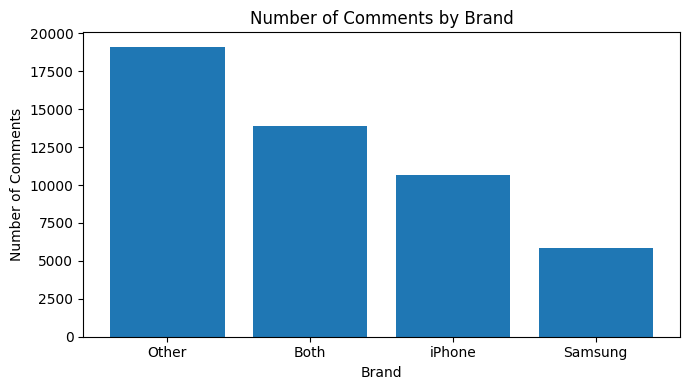

In [48]:
#Plot comments by brand
plt.figure(figsize=(7,4))
plt.bar(brand_counts.index, brand_counts.values)

plt.title("Number of Comments by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

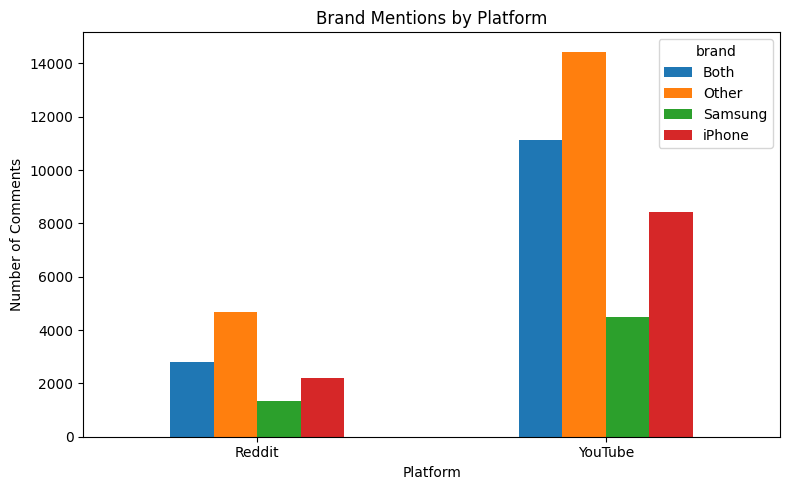

In [49]:
#Compare brand mentions across platforms
platform_brand_counts = pd.crosstab(all_comments["platform"], all_comments["brand"])

platform_brand_counts
#Plot brand mentions by platform
platform_brand_counts.plot(kind="bar", figsize=(8,5))

plt.title("Brand Mentions by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [50]:
#Create comment length columns if they do not already exist
all_comments["text_length"] = all_comments["clean_comment_basic"].str.len()
all_comments["word_count"] = all_comments["clean_comment_basic"].str.split().str.len()

display(all_comments[["platform", "brand", "clean_comment_basic", "word_count"]].head())

,platform,brand,clean_comment_basic,word_count
0,Reddit,Other,its also a great fruit,5
1,Reddit,Other,their products are original and superior,6
2,Reddit,Other,that is some good delulu juice you ve been dri...,10
3,Reddit,Both,i mean i ll cheer because it ll be about damn ...,19
4,Reddit,Other,more then that having to scroll through the se...,18


In [51]:
#Check skewness of comment length
word_count_skew = all_comments["word_count"].skew()
text_length_skew = all_comments["text_length"].skew()

print("Word count skewness:", word_count_skew)
print("Text length skewness:", text_length_skew)

Word count skewness: 5.203996065982601
Text length skewness: 5.2669748005390105


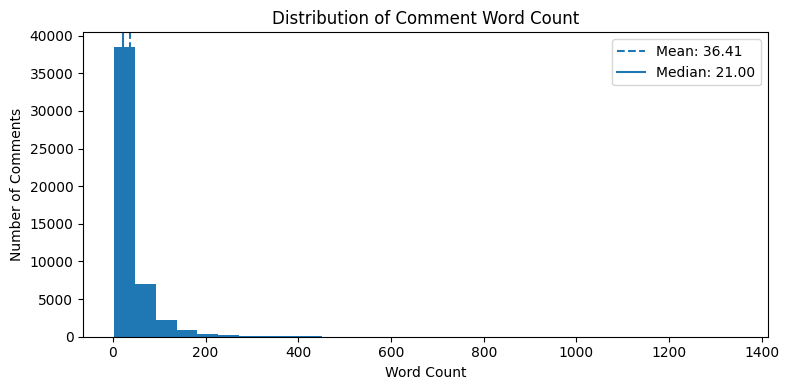

In [52]:
#Plot word count distribution with mean and median
mean_word_count = all_comments["word_count"].mean()
median_word_count = all_comments["word_count"].median()

plt.figure(figsize=(8,4))
plt.hist(all_comments["word_count"], bins=30)

plt.axvline(mean_word_count, linestyle="--", label=f"Mean: {mean_word_count:.2f}")
plt.axvline(median_word_count, linestyle="-", label=f"Median: {median_word_count:.2f}")

plt.title("Distribution of Comment Word Count")
plt.xlabel("Word Count")
plt.ylabel("Number of Comments")
plt.legend()

plt.tight_layout()
plt.show()

Word counts are heavily skewed to the right, which is exactly what we expected for social media data. Most comments are short reactions under 50 words but there is a long tail of much longer comments where people are making detailed arguments. The median of 21 words sits well below the mean of 36.41, which shows how much those longer comments pull the average up.

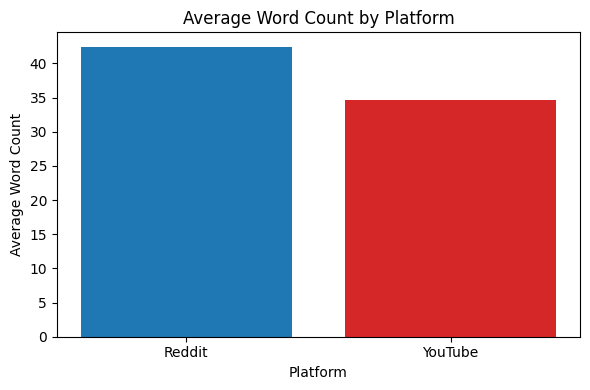

platform
Reddit     42.41
YouTube    34.69
Name: word_count, dtype: float64


In [54]:
# comparing average word count by platform
avg_word_platform = all_comments.groupby("platform")["word_count"].mean()

plt.figure(figsize=(6,4))
plt.bar(avg_word_platform.index, avg_word_platform.values, color=["#1f77b4", "#d62728"])
plt.title("Average Word Count by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Word Count")
plt.tight_layout()
plt.show()

print(avg_word_platform.round(2))

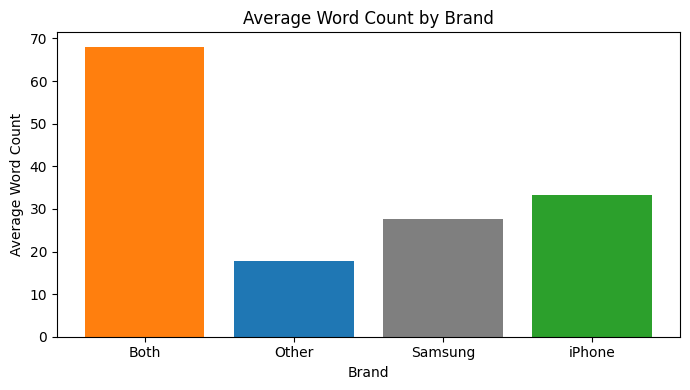

brand
Both       68.04
Other      17.82
Samsung    27.68
iPhone     33.21
Name: word_count, dtype: float64


In [55]:
# comparing average word count by brand
avg_word_brand = all_comments.groupby("brand")["word_count"].mean()

plt.figure(figsize=(7,4))
plt.bar(avg_word_brand.index, avg_word_brand.values, color=["#ff7f0e", "#1f77b4", "#7f7f7f", "#2ca02c"])
plt.title("Average Word Count by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Word Count")
plt.tight_layout()
plt.show()

print(avg_word_brand.round(2))

## Word Frequency

In [57]:
#Count common words from cleaned comments
all_words = Counter()

for comment in all_comments["clean_comment_lemma"]:
    all_words.update(str(comment).split())

print("Top 20 words:")
for word, count in all_words.most_common(20):
    print(f"{word}: {count}")

Top 20 words:
android: 23487
iphone: 18954
apple: 18043
phone: 16319
like: 9943
use: 9306
samsung: 8107
one: 6581
io: 6341
year: 6294
apps: 6258
thing: 5724
better: 5691
people: 5618
get: 5570
ecosystem: 4882
google: 4834
even: 4805
work: 4669
user: 4302


## Word Frequency by Brand

In [59]:
#Separate comments by brand
iphone_comments = all_comments[all_comments["brand"].isin(["iPhone", "Both"])]
samsung_comments = all_comments[all_comments["brand"].isin(["Samsung", "Both"])]

We made separate word clouds for iPhone and Samsung comments to get a quick visual sense of what each community talks about. We removed brand names from the opposite brand cloud so the results would show genuine discussion topics rather than just the brand name itself dominating everything.

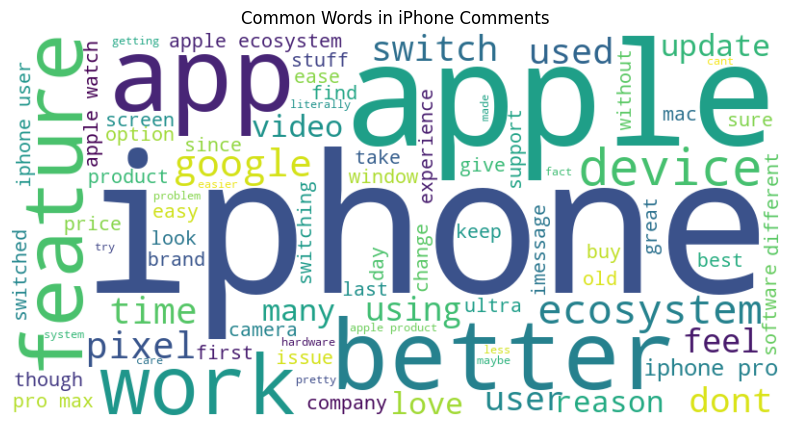

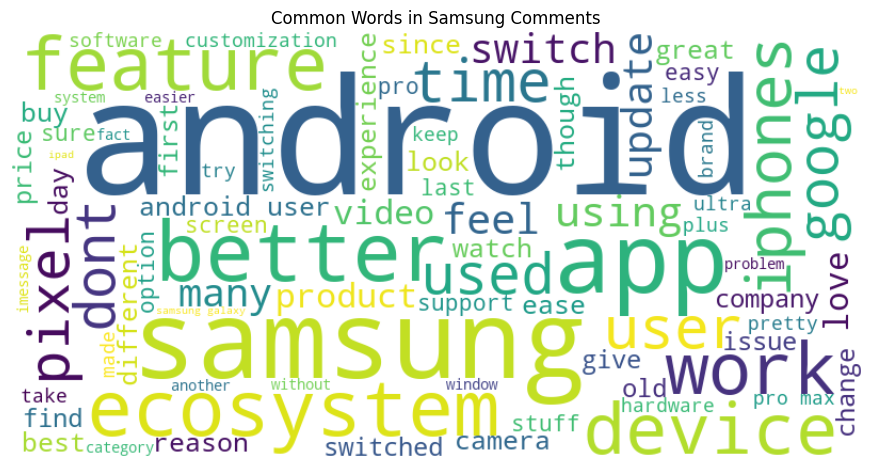

In [61]:
# custom stopwords to clean up word clouds
base_stopwords = [
    "phone", "like", "use", "get", "one", "also", "even", "still",
    "thing", "things", "good", "really", "much", "well", "people",
    "way", "make", "know", "think", "want", "need", "say", "said",
    "year", "new", "back", "going", "right", "thats", "io", "lol",
    "etc", "yes", "got", "lot", "come", "see", "mean", "point",
    "actually", "always", "alway", "everything", "anything", "something",
    "nothing", "every", "never", "just", "would", "could", "should"
]

# iPhone word cloud - remove Samsung brand words
iphone_stopwords = base_stopwords + ["samsung", "galaxy", "android"]

# Samsung word cloud - remove iPhone brand words  
samsung_stopwords = base_stopwords + ["iphone", "apple", "ios"]

# iPhone word cloud
iphone_text = " ".join(iphone_comments["clean_comment_lemma"].astype(str))
wordcloud = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=80,
    stopwords=set(iphone_stopwords)
).generate(iphone_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in iPhone Comments")
plt.show()

# Samsung word cloud
samsung_text = " ".join(samsung_comments["clean_comment_lemma"].astype(str))
wordcloud = WordCloud(
    width=800, height=400,
    background_color="white",
    max_words=80,
    stopwords=set(samsung_stopwords)
).generate(samsung_text)

plt.figure(figsize=(11, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Samsung Comments")
plt.show()

# 5. Sentiment Analysis

In this section we looked at how positive or negative the comments were across both platforms and both brands. We used VADER to do this because it was built specifically for social media text and handles informal language and short comments well. Each comment gets a compound score between -1 and +1. We also ran Mann-Whitney U tests to check whether the differences we found were statistically meaningful rather than just noise.

In [63]:
# installing VADER
#!pip install vaderSentiment -q

In [64]:
# importing VADER and running sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# applying VADER on clean_comment_basic not lemma
# because VADER needs original word forms to detect sentiment correctly
analysis_df["vader_compound"] = analysis_df["clean_comment_basic"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

# labelling sentiment using standard VADER thresholds
def label_sentiment(score):
    if score >= 0.05:  return "Positive"
    if score <= -0.05: return "Negative"
    return "Neutral"

analysis_df["sentiment"] = analysis_df["vader_compound"].apply(label_sentiment)

print("Sentiment distribution:")
print(analysis_df["sentiment"].value_counts())
print(f"\nAverage compound score overall: {analysis_df['vader_compound'].mean():.4f}")

Sentiment distribution:
sentiment
Positive    18261
Negative     6427
Neutral      5692
Name: count, dtype: int64

Average compound score overall: 0.2711


## Sentiment Distribution by Brand

We compared sentiment scores across iPhone, Samsung, and Both brand comments using a boxplot with a strip overlay. This shows not just the average but the full spread of scores for each group.

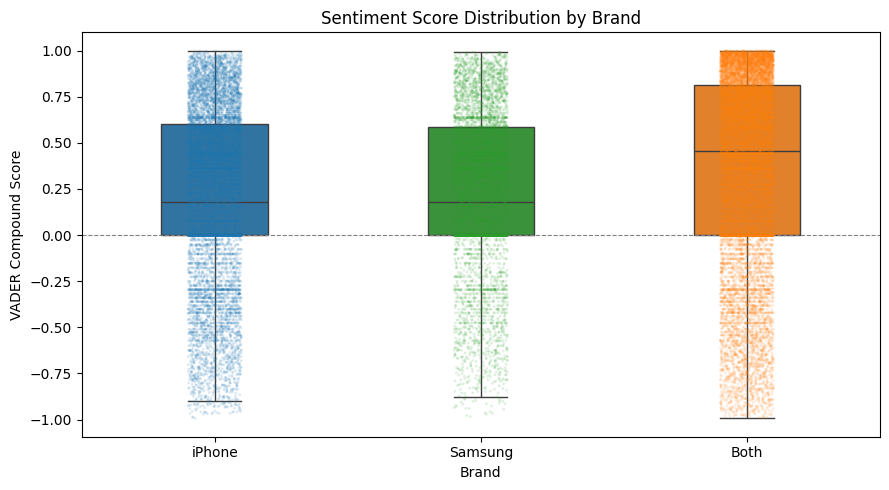

Average sentiment score by brand:
brand
Both       0.3517
Samsung    0.2182
iPhone     0.1945
Name: vader_compound, dtype: float64


In [66]:
# plotting sentiment distribution by brand - boxplot with data points overlay
plt.figure(figsize=(9, 5))

palette = {"iPhone": "#1f77b4", "Samsung": "#2ca02c", "Both": "#ff7f0e"}
order = ["iPhone", "Samsung", "Both"]

# strip plot first so boxes appear on top
sns.stripplot(
    data=analysis_df,
    x="brand",
    y="vader_compound",
    hue="brand",
    palette=palette,
    order=order,
    alpha=0.15,
    size=2,
    legend=False
)

sns.boxplot(
    data=analysis_df,
    x="brand",
    y="vader_compound",
    hue="brand",
    palette=palette,
    order=order,
    width=0.4,
    fliersize=0,
    legend=False
)

plt.axhline(0, linestyle="--", color="grey", linewidth=0.8)
plt.title("Sentiment Score Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("VADER Compound Score")
plt.tight_layout()
plt.show()

print("Average sentiment score by brand:")
print(analysis_df.groupby("brand")["vader_compound"].mean().round(4))

Samsung came out slightly more positive on average at 0.22 compared to iPhone at 0.19. One explanation for this is that Samsung users have often actively chosen Android over iPhone and feel satisfied with that decision, which drives positive sentiment. iPhone users include a lot of people who are frustrated with specific features or evaluating whether to switch, which pulls the average down slightly. What stood out most was that comments mentioning both brands scored noticeably higher at 0.35. This makes sense because people comparing both brands in the same comment are usually in a more open and analytical mindset rather than defending one choice.

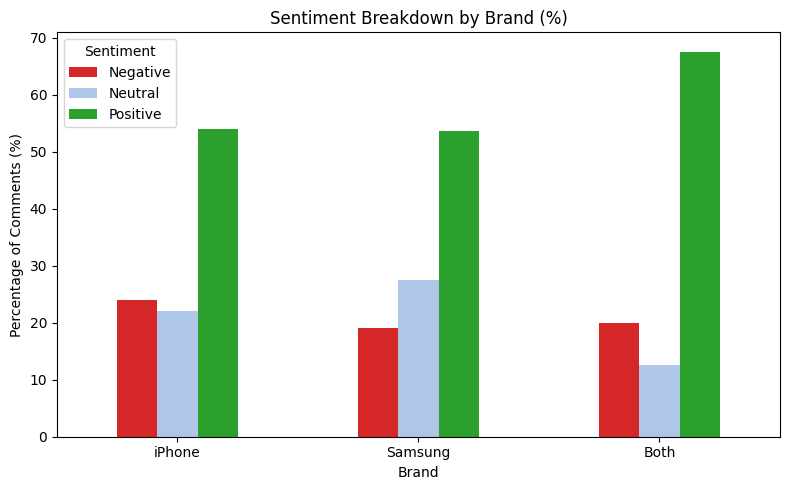

sentiment  Negative  Neutral  Positive
brand                                 
iPhone        23.98    22.04     53.98
Samsung       19.02    27.42     53.55
Both          19.89    12.58     67.53


In [68]:
# plotting sentiment breakdown by brand as percentage stacked bar
sentiment_brand = pd.crosstab(
    analysis_df["brand"],
    analysis_df["sentiment"],
    normalize="index"
) * 100

sentiment_brand = sentiment_brand.reindex(["iPhone", "Samsung", "Both"])

sentiment_brand.plot(
    kind="bar",
    figsize=(8, 5),
    color={"Positive": "#2ca02c", "Neutral": "#aec7e8", "Negative": "#d62728"}
)
plt.title("Sentiment Breakdown by Brand (%)")
plt.xlabel("Brand")
plt.ylabel("Percentage of Comments (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

print(sentiment_brand.round(2))

The positive rates for iPhone and Samsung were almost identical at 54.0% and 53.6%. Where they differed was in the negative versus neutral split. iPhone had a higher negative rate at 24% compared to Samsung at 19%, which tells us iPhone users are more emotionally reactive when something does not meet expectations. Samsung had more neutral comments at 27%, pointing to a community that tends to discuss features more factually. Both brand comments stood out again with 67.5% positive and only 12.6% neutral, which shows that comparison discussions really are more enthusiastic overall.

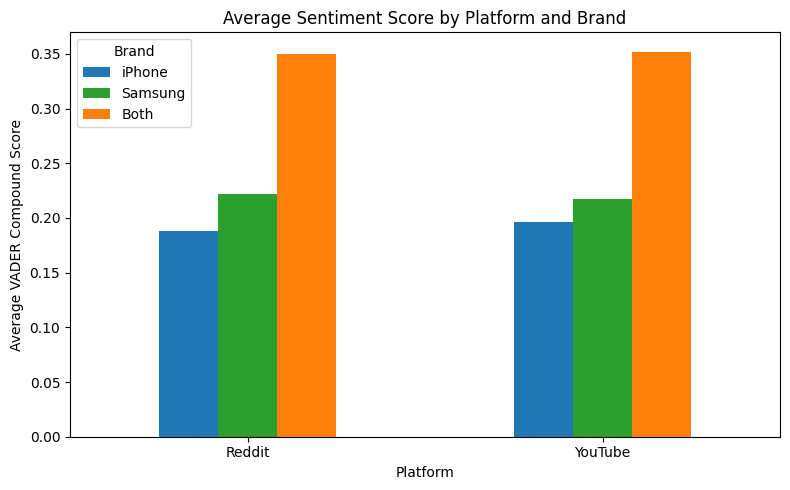

brand     iPhone  Samsung    Both
platform                         
Reddit    0.1879   0.2223  0.3503
YouTube   0.1962   0.2170  0.3521


In [70]:
# comparing average sentiment across platform and brand
platform_brand_sentiment = analysis_df.groupby(
    ["platform", "brand"]
)["vader_compound"].mean().unstack()

platform_brand_sentiment = platform_brand_sentiment[["iPhone", "Samsung", "Both"]]

platform_brand_sentiment.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1f77b4", "#2ca02c", "#ff7f0e"]
)
plt.title("Average Sentiment Score by Platform and Brand")
plt.xlabel("Platform")
plt.ylabel("Average VADER Compound Score")
plt.xticks(rotation=0)
plt.axhline(0, linestyle="--", color="grey", linewidth=0.8)
plt.legend(title="Brand")
plt.tight_layout()
plt.show()

print(platform_brand_sentiment.round(4))

When we split by platform the numbers were almost identical. Reddit iPhone scored 0.19 and YouTube iPhone scored 0.20. Reddit Samsung scored 0.2223 and YouTube Samsung scored 0.2170. The platform does not seem to change how people feel about these brands at all. What it does change is how they express those feelings and how deeply they engage with each other, which we get into more in the network sections.

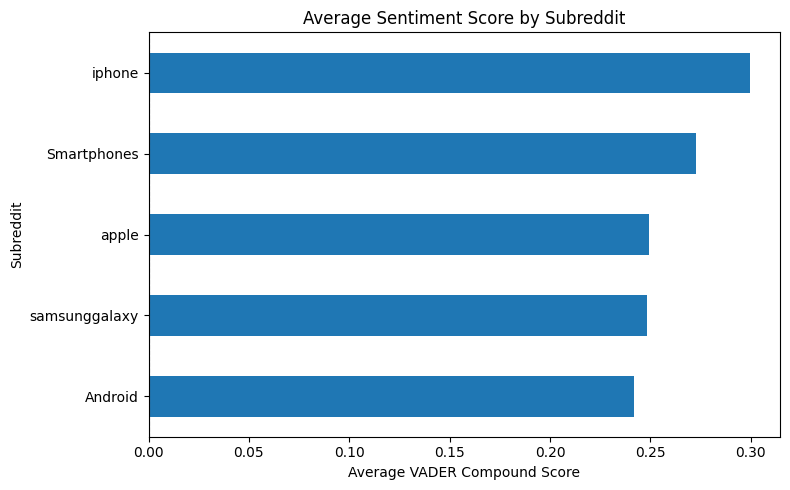

community
Android          0.2418
samsunggalaxy    0.2483
apple            0.2491
Smartphones      0.2726
iphone           0.2996
Name: vader_compound, dtype: float64


In [72]:
# plotting average sentiment by subreddit - Reddit only
reddit_sentiment_df = analysis_df[analysis_df["platform"] == "Reddit"].copy()

subreddit_sentiment = reddit_sentiment_df.groupby("community")["vader_compound"].mean().sort_values()

plt.figure(figsize=(8, 5))
subreddit_sentiment.plot(kind="barh", color="#1f77b4")
plt.axvline(0, linestyle="--", color="grey", linewidth=0.8)
plt.title("Average Sentiment Score by Subreddit")
plt.xlabel("Average VADER Compound Score")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

print(subreddit_sentiment.round(4))

Looking at individual subreddits, r/iphone had the highest average sentiment at 0.30 and r/Android the lowest at 0.24. The reason for this makes sense when you think about who is in each community. r/iphone is made up of people who already own and enjoy their iPhones so the baseline tone is positive. r/Android covers all Android manufacturers and includes more technical and critical discussions about updates and fragmentation, which brings the average down. What we found interesting was that r/iphone scored above even r/apple at 0.25, suggesting that iPhone device users are more positive than Apple brand followers generally. r/Smartphones sat in the middle at 0.27 as a neutral comparison space. Even at 0.24, r/Android was still moderately positive, which tells us that even the most critical tech communities are not truly negative about the brands they discuss.

In [74]:
# Checking whether the sentiment gaps we observed are statistically meaningful
# or just random noise. VADER scores cluster around 0 and at the extremes,
# so they are not normal - using the Mann-Whitney U test which does not assume normality.

from scipy.stats import mannwhitneyu

# pulling out sentiment scores per group once so we do not repeat filtering
iphone_vader  = analysis_df.loc[analysis_df["brand"] == "iPhone",  "vader_compound"].values
samsung_vader = analysis_df.loc[analysis_df["brand"] == "Samsung", "vader_compound"].values
both_vader    = analysis_df.loc[analysis_df["brand"] == "Both",    "vader_compound"].values

# helper to describe how strong a p-value and effect size are
def describe_pvalue(p):
    if p < 0.001: return "highly significant (p<0.001)"
    if p < 0.01:  return "very significant (p<0.01)"
    if p < 0.05:  return "significant (p<0.05)"
    return "not significant"

def describe_effect(r):
    size = abs(r)
    if size < 0.1: return "negligible"
    if size < 0.3: return "small"
    if size < 0.5: return "medium"
    return "large"

# running the test between two sentiment arrays and printing a readable summary
def run_test(group1, group2, name1, name2):
    n1, n2 = len(group1), len(group2)
    u_value, p_value = mannwhitneyu(group1, group2, alternative="two-sided")
    
    # rank-biserial correlation tells us how large the difference is, not just whether it exists
    rb_effect = 1 - (2 * u_value) / (n1 * n2)
    
    mean1, mean2 = group1.mean(), group2.mean()
    med1,  med2  = pd.Series(group1).median(), pd.Series(group2).median()
    
    print(f"\n{name1} vs {name2}")
    print(f"   {name1}: n={n1:,} mean={mean1:.4f} median={med1:.4f}")
    print(f"   {name2}: n={n2:,} mean={mean2:.4f} median={med2:.4f}")
    print(f"   U={u_value:,.0f}, p={p_value:.2e}, effect r={rb_effect:+.4f}")
    print(f"   -> {describe_pvalue(p_value)}, effect is {describe_effect(rb_effect)}")

In [75]:
# brand-vs-brand comparisons
print("Brand comparisons")

run_test(iphone_vader,  samsung_vader, "iPhone",  "Samsung")
run_test(iphone_vader,  both_vader,    "iPhone",  "Both")
run_test(samsung_vader, both_vader,    "Samsung", "Both")

# checking whether the same brand is treated differently on each platform
print("\n\nPlatform comparisons within each brand")


for brand_name in ["iPhone", "Samsung", "Both"]:
    on_reddit  = analysis_df.loc[
        (analysis_df["brand"] == brand_name) & (analysis_df["platform"] == "Reddit"),
        "vader_compound"
    ].values
    on_youtube = analysis_df.loc[
        (analysis_df["brand"] == brand_name) & (analysis_df["platform"] == "YouTube"),
        "vader_compound"
    ].values
    run_test(on_reddit, on_youtube, f"Reddit-{brand_name}", f"YouTube-{brand_name}")

Brand comparisons

iPhone vs Samsung
   iPhone: n=10,632 mean=0.1945 median=0.1779
   Samsung: n=5,824 mean=0.2182 median=0.1779
   U=30,305,806, p=2.39e-02, effect r=+0.0211
   -> significant (p<0.05), effect is negligible

iPhone vs Both
   iPhone: n=10,632 mean=0.1945 median=0.1779
   Both: n=13,924 mean=0.3517 median=0.4558
   U=58,510,090, p=3.00e-175, effect r=+0.2095
   -> highly significant (p<0.001), effect is small

Samsung vs Both
   Samsung: n=5,824 mean=0.2182 median=0.1779
   Both: n=13,924 mean=0.3517 median=0.4558
   U=32,598,166, p=2.57e-105, effect r=+0.1960
   -> highly significant (p<0.001), effect is small


Platform comparisons within each brand

Reddit-iPhone vs YouTube-iPhone
   Reddit-iPhone: n=2,218 mean=0.1879 median=0.1978
   YouTube-iPhone: n=8,414 mean=0.1962 median=0.1779
   U=9,315,760, p=9.05e-01, effect r=+0.0016
   -> not significant, effect is negligible

Reddit-Samsung vs YouTube-Samsung
   Reddit-Samsung: n=1,335 mean=0.2223 median=0.2263
   YouTub

Three things stood out from the tests. 
First, the iPhone versus Samsung difference was statistically significant at p = 0.024 but the effect size was negligible at r = 0.021. With over 16,000 comments even tiny gaps show up as significant so the two brands are practically almost the same. 

Second, both brand comments were genuinely more positive than single brand comments with a small but real effect size of r = 0.20. 

Third, we found no significant difference between Reddit and YouTube sentiment for any brand, which confirms that platform does not change how people emotionally feel about these brands.

# 6. Topic Modelling

In this section we used LDA to discover what topics each brand community actually talks about. LDA finds the topics from the text itself without us telling it what to look for. We ran it separately on iPhone and Samsung comments so we could compare what each community focuses on. We used coherence scoring to pick the right number of topics rather than just guessing.

In [78]:
# installing required libraries for LDA
#%pip install pyLDAvis gensim -q

In [79]:
# importing libraries needed for topic modelling
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [80]:
# preparing separate corpora for iPhone and Samsung comments
# using clean_comment_lemma since stopwords are already removed and words are lemmatised

iphone_docs  = analysis_df[analysis_df["brand"] == "iPhone"]["clean_comment_lemma"].astype(str).tolist()
samsung_docs = analysis_df[analysis_df["brand"] == "Samsung"]["clean_comment_lemma"].astype(str).tolist()

# tokenising each comment into a list of words
iphone_tokens  = [doc.split() for doc in iphone_docs]
samsung_tokens = [doc.split() for doc in samsung_docs]

# building dictionaries and bag of words corpus for each brand
iphone_dict   = corpora.Dictionary(iphone_tokens)
samsung_dict  = corpora.Dictionary(samsung_tokens)

iphone_corpus  = [iphone_dict.doc2bow(doc) for doc in iphone_tokens]
samsung_corpus = [samsung_dict.doc2bow(doc) for doc in samsung_tokens]

print(f"iPhone  - documents: {len(iphone_tokens)}, unique words: {len(iphone_dict)}")
print(f"Samsung - documents: {len(samsung_tokens)}, unique words: {len(samsung_dict)}")

iPhone  - documents: 10632, unique words: 11186
Samsung - documents: 5824, unique words: 7516


In [81]:
import pickle
import os
from gensim.models import LdaMulticore
from gensim import corpora

# create models folder if it does not exist
os.makedirs("models", exist_ok=True)

models_loaded = False

if os.path.exists("models/iphone_lda.model") and os.path.exists("models/samsung_lda.model"):
    try:
        print("Loading saved models...")
        iphone_lda   = LdaMulticore.load("models/iphone_lda.model")
        samsung_lda  = LdaMulticore.load("models/samsung_lda.model")
        iphone_dict  = corpora.Dictionary.load("models/iphone_dict.dict")
        samsung_dict = corpora.Dictionary.load("models/samsung_dict.dict")
        with open("models/iphone_corpus.pkl", "rb") as f:
            iphone_corpus = pickle.load(f)
        with open("models/samsung_corpus.pkl", "rb") as f:
            samsung_corpus = pickle.load(f)
        with open("models/iphone_coherence.pkl", "rb") as f:
            iphone_coherence = pickle.load(f)
        with open("models/samsung_coherence.pkl", "rb") as f:
            samsung_coherence = pickle.load(f)
        models_loaded = True
        print("Done - skipping retraining")
    except (ModuleNotFoundError, AttributeError, EOFError, ImportError) as e:
        print(f"Cached models incompatible ({e}). Will retrain.")

if not models_loaded:
    print("Training now (one time only)...")
    
    def compute_coherence(dictionary, corpus, texts, start=2, limit=15, step=1):
        coherence_scores = []
        for k in range(start, limit + 1, step):
            model = LdaMulticore(
                corpus=corpus, id2word=dictionary, num_topics=k,
                random_state=42, passes=10, workers=4
            )
            cm = CoherenceModel(
                model=model, texts=texts,
                dictionary=dictionary, coherence="c_v"
            )
            score = cm.get_coherence()
            coherence_scores.append((k, score))
            print(f"  k={k} coherence={score:.4f}")
        return coherence_scores
    
    print("Computing coherence scores for iPhone corpus...")
    iphone_coherence = compute_coherence(iphone_dict, iphone_corpus, iphone_tokens)
    print("\nComputing coherence scores for Samsung corpus...")
    samsung_coherence = compute_coherence(samsung_dict, samsung_corpus, samsung_tokens)
    
    iphone_lda = LdaMulticore(
        corpus=iphone_corpus, id2word=iphone_dict,
        num_topics=5, random_state=42, passes=15, workers=4
    )
    samsung_lda = LdaMulticore(
        corpus=samsung_corpus, id2word=samsung_dict,
        num_topics=5, random_state=42, passes=15, workers=4
    )
    
    iphone_lda.save("models/iphone_lda.model")
    samsung_lda.save("models/samsung_lda.model")
    iphone_dict.save("models/iphone_dict.dict")
    samsung_dict.save("models/samsung_dict.dict")
    with open("models/iphone_corpus.pkl", "wb") as f:
        pickle.dump(iphone_corpus, f)
    with open("models/samsung_corpus.pkl", "wb") as f:
        pickle.dump(samsung_corpus, f)
    with open("models/iphone_coherence.pkl", "wb") as f:
        pickle.dump(iphone_coherence, f)
    with open("models/samsung_coherence.pkl", "wb") as f:
        pickle.dump(samsung_coherence, f)
    print("Models trained and saved in models/ folder")

print(f"\niPhone LDA: {iphone_lda.num_topics} topics")
print(f"Samsung LDA: {samsung_lda.num_topics} topics")

Loading saved models...
Done - skipping retraining

iPhone LDA: 5 topics
Samsung LDA: 5 topics


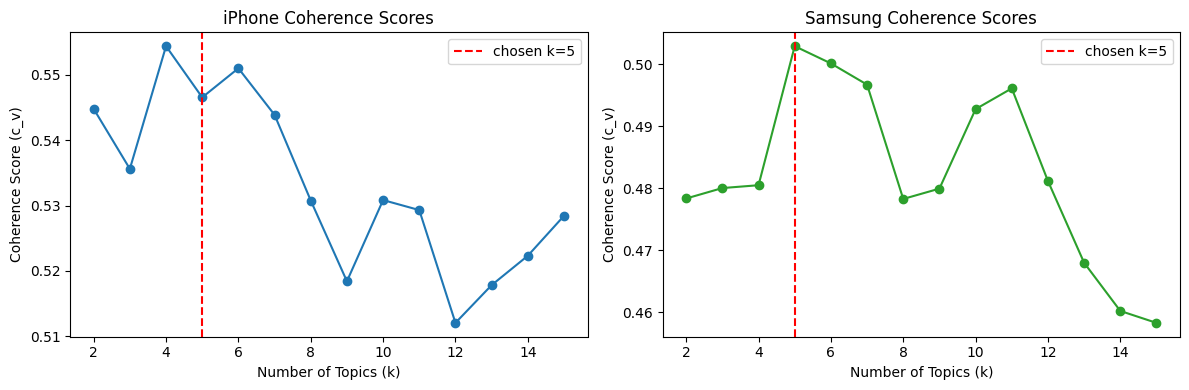

In [82]:
# plotting coherence scores to justify chosen k for both brands
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# iPhone coherence plot
iphone_ks     = [x[0] for x in iphone_coherence]
iphone_scores = [x[1] for x in iphone_coherence]

axes[0].plot(iphone_ks, iphone_scores, marker="o", color="#1f77b4")
axes[0].axvline(5, linestyle="--", color="red", label="chosen k=5")
axes[0].set_title("iPhone Coherence Scores")
axes[0].set_xlabel("Number of Topics (k)")
axes[0].set_ylabel("Coherence Score (c_v)")
axes[0].legend()

# Samsung coherence plot
samsung_ks     = [x[0] for x in samsung_coherence]
samsung_scores = [x[1] for x in samsung_coherence]

axes[1].plot(samsung_ks, samsung_scores, marker="o", color="#2ca02c")
axes[1].axvline(5, linestyle="--", color="red", label="chosen k=5")
axes[1].set_title("Samsung Coherence Scores")
axes[1].set_xlabel("Number of Topics (k)")
axes[1].set_ylabel("Coherence Score (c_v)")
axes[1].legend()

plt.tight_layout()
plt.show()

We tested coherence scores from k=2 to k=15 for both brands. For iPhone, k=5 gave us the best balance between coherence and interpretability. Higher values started producing overlapping topics that were hard to label meaningfully. For Samsung, coherence peaked at k=5 as well, making it a natural choice for both. Using the same k for both means any differences we see in the topics reflect genuine community differences rather than model differences.

In [84]:
# printing top words for each topic in both models
print("iPhone Topics:")

for idx, topic in iphone_lda.print_topics(num_words=8):
    print(f"Topic {idx + 1}: {topic}")

print("\nSamsung Topics:")

for idx, topic in samsung_lda.print_topics(num_words=8):
    print(f"Topic {idx + 1}: {topic}")

iPhone Topics:
Topic 1: 0.059*"iphone" + 0.026*"apple" + 0.020*"phone" + 0.015*"year" + 0.014*"pro" + 0.013*"pixel" + 0.011*"back" + 0.010*"switch"
Topic 2: 0.049*"apple" + 0.027*"iphone" + 0.021*"phone" + 0.013*"ecosystem" + 0.011*"watch" + 0.011*"use" + 0.010*"switch" + 0.010*"ipad"
Topic 3: 0.060*"apple" + 0.018*"iphone" + 0.012*"like" + 0.011*"imessage" + 0.010*"ecosystem" + 0.010*"people" + 0.007*"reason" + 0.007*"switch"
Topic 4: 0.036*"iphone" + 0.017*"io" + 0.015*"like" + 0.014*"people" + 0.013*"iphones" + 0.012*"use" + 0.011*"better" + 0.010*"app"
Topic 5: 0.043*"apple" + 0.023*"google" + 0.019*"iphone" + 0.013*"face" + 0.011*"phone" + 0.010*"use" + 0.009*"pixel" + 0.009*"like"

Samsung Topics:
Topic 1: 0.079*"android" + 0.036*"phone" + 0.017*"use" + 0.012*"like" + 0.010*"people" + 0.010*"one" + 0.008*"make" + 0.007*"better"
Topic 2: 0.053*"android" + 0.020*"phone" + 0.013*"app" + 0.011*"samsung" + 0.011*"use" + 0.010*"google" + 0.010*"feature" + 0.009*"would"
Topic 3: 0.082*"

After training both models we looked at the top keywords for each topic and labelled them manually. We found five iPhone topics: General Apple and iOS, Switching Experience, App Ecosystem, Apple Ecosystem and Products, and Camera and Video Quality. For Samsung we found: General Usage Experience, Brand Dominance, Android Platform, Camera Quality, and Galaxy Flagship Models. The most notable pattern we noticed was that Android appears across every Samsung topic while iPhone topics stay centred on Apple specific language. Samsung communities are framing their brand against competitors and the broader Android platform, while iPhone communities discuss the Apple experience more directly. Google Pixel appeared in topics from both brands, suggesting it is a common reference point when people compare smartphones.

In [86]:
# assigning topic labels based on top keywords
iphone_topic_labels = {
    0: "General Apple & iOS",
    1: "Switching Experience",
    2: "App Ecosystem",
    3: "Apple Ecosystem & Products",
    4: "Camera & Video Quality"
}

samsung_topic_labels = {
    0: "General Usage Experience",
    1: "Brand Dominance",
    2: "Android Platform",
    3: "Camera Quality",
    4: "Galaxy Flagship Models"
}
# assigning dominant topic to each comment
def get_dominant_topic(lda_model, corpus):
    topics = []
    for bow in corpus:
        topic_dist = lda_model.get_document_topics(bow)
        dominant   = max(topic_dist, key=lambda x: x[1])[0]
        topics.append(dominant)
    return topics

# applying to iPhone and Samsung subsets
iphone_idx  = analysis_df[analysis_df["brand"] == "iPhone"].index
samsung_idx = analysis_df[analysis_df["brand"] == "Samsung"].index

analysis_df.loc[iphone_idx, "topic_id"]    = get_dominant_topic(iphone_lda, iphone_corpus)
analysis_df.loc[samsung_idx, "topic_id"]   = get_dominant_topic(samsung_lda, samsung_corpus)

analysis_df.loc[iphone_idx, "topic_label"]  = analysis_df.loc[iphone_idx, "topic_id"].map(iphone_topic_labels)
analysis_df.loc[samsung_idx, "topic_label"] = analysis_df.loc[samsung_idx, "topic_id"].map(samsung_topic_labels)

print("Topic assignment done")
print("\niPhone topic distribution:")
print(analysis_df[analysis_df["brand"] == "iPhone"]["topic_label"].value_counts())
print("\nSamsung topic distribution:")
print(analysis_df[analysis_df["brand"] == "Samsung"]["topic_label"].value_counts())

Topic assignment done

iPhone topic distribution:
topic_label
General Apple & iOS           2939
Apple Ecosystem & Products    2394
Switching Experience          2208
Camera & Video Quality        1674
App Ecosystem                 1417
Name: count, dtype: int64

Samsung topic distribution:
topic_label
Android Platform            1563
General Usage Experience    1422
Camera Quality              1043
Galaxy Flagship Models      1014
Brand Dominance              782
Name: count, dtype: int64


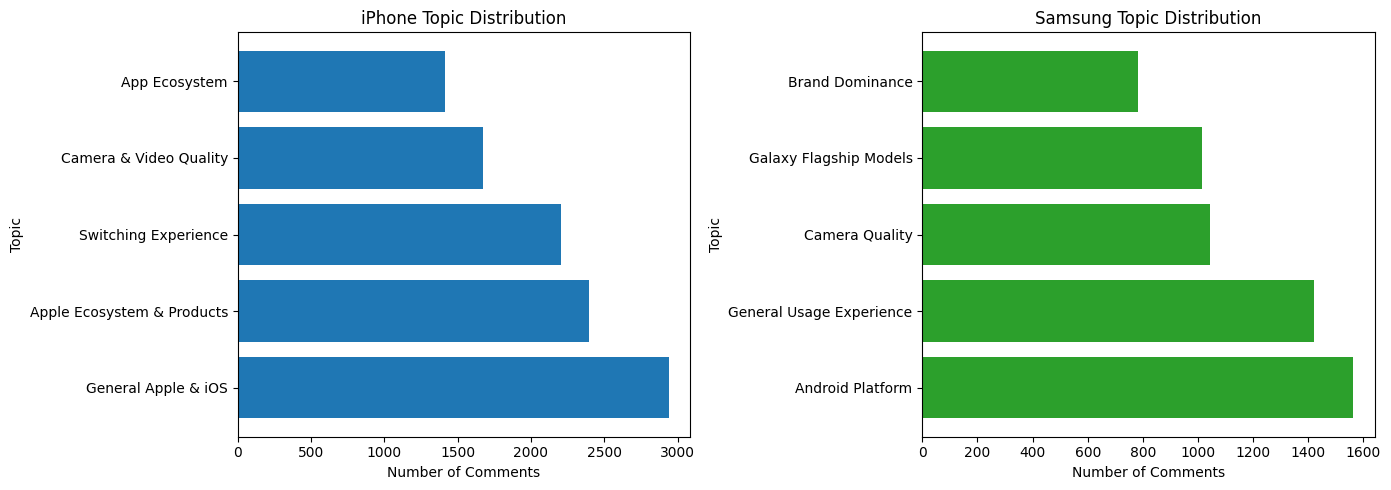

In [87]:
# plotting topic distribution for both brands side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# iPhone topic distribution
iphone_topics = analysis_df[analysis_df["brand"] == "iPhone"]["topic_label"].value_counts()
axes[0].barh(iphone_topics.index, iphone_topics.values, color="#1f77b4")
axes[0].set_title("iPhone Topic Distribution")
axes[0].set_xlabel("Number of Comments")
axes[0].set_ylabel("Topic")

# Samsung topic distribution
samsung_topics = analysis_df[analysis_df["brand"] == "Samsung"]["topic_label"].value_counts()
axes[1].barh(samsung_topics.index, samsung_topics.values, color="#2ca02c")
axes[1].set_title("Samsung Topic Distribution")
axes[1].set_xlabel("Number of Comments")
axes[1].set_ylabel("Topic")

plt.tight_layout()
plt.show()

The topic distributions showed that each community has a genuinely different focus. For iPhone, General Apple and iOS was the most discussed topic with 2,939 comments, followed by Apple Ecosystem and Products at 2,394 and Switching Experience at 2,208. This tells us iPhone discussions span three overlapping registers: broad iOS and Apple experience, how the phone fits into the wider Apple device family, and decisions around switching between brands. Ecosystem framing remains a major theme even when it isn't the largest topic. For Samsung, Android Platform led with 1,563 comments and General Usage Experience followed closely at 1,422. We found it interesting that the top Samsung topic was Android Platform rather than any Samsung-specific hardware topic. It suggests Samsung users identify more with Android as a platform than with Samsung as a brand specifically.

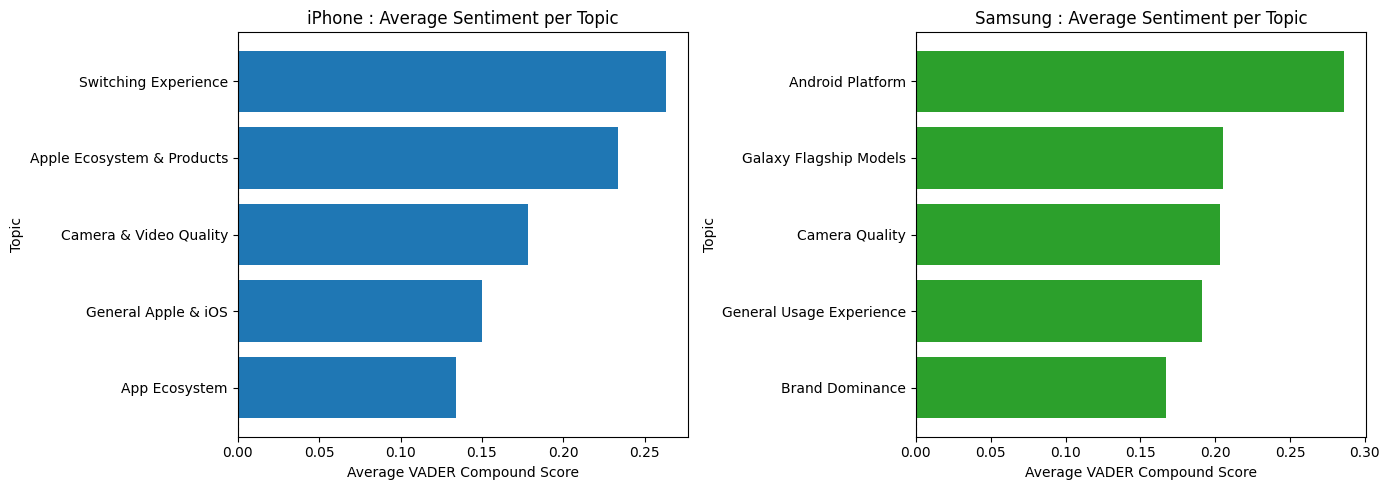

iPhone sentiment per topic:
topic_label
App Ecosystem                 0.1338
General Apple & iOS           0.1497
Camera & Video Quality        0.1781
Apple Ecosystem & Products    0.2335
Switching Experience          0.2630
Name: vader_compound, dtype: float64

Samsung sentiment per topic:
topic_label
Brand Dominance             0.1670
General Usage Experience    0.1915
Camera Quality              0.2031
Galaxy Flagship Models      0.2055
Android Platform            0.2863
Name: vader_compound, dtype: float64


In [89]:
# plotting sentiment per topic for each brand
# this shows which topics carry positive vs negative sentiment

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# iPhone sentiment per topic
iphone_topic_sentiment = (
    analysis_df[analysis_df["brand"] == "iPhone"]
    .groupby("topic_label")["vader_compound"].mean().sort_values()
)
axes[0].barh(iphone_topic_sentiment.index, iphone_topic_sentiment.values, color="#1f77b4")
axes[0].axvline(0, linestyle="--", color="grey", linewidth=0.8)
axes[0].set_title("iPhone : Average Sentiment per Topic")
axes[0].set_xlabel("Average VADER Compound Score")
axes[0].set_ylabel("Topic")

# Samsung sentiment per topic
samsung_topic_sentiment = (
    analysis_df[analysis_df["brand"] == "Samsung"]
    .groupby("topic_label")["vader_compound"].mean().sort_values()
)
axes[1].barh(samsung_topic_sentiment.index, samsung_topic_sentiment.values, color="#2ca02c")
axes[1].axvline(0, linestyle="--", color="grey", linewidth=0.8)
axes[1].set_title("Samsung : Average Sentiment per Topic")
axes[1].set_xlabel("Average VADER Compound Score")
axes[1].set_ylabel("Topic")

plt.tight_layout()
plt.show()

print("iPhone sentiment per topic:")
print(iphone_topic_sentiment.round(4))
print("\nSamsung sentiment per topic:")
print(samsung_topic_sentiment.round(4))

Looking at sentiment per topic, we found that Switching Experience was the most positive iPhone topic at 0.26. This makes sense because users discussing a switch to or from iPhone tend to be sharing the positive outcome of a decision they already made rather than venting about an ongoing frustration. App Ecosystem was the least positive iPhone topic at 0.13, which reflects that app-related discussion often surfaces frustrations around missing or restricted apps and subscription costs. For Samsung, Android Platform came out as the most positive topic at 0.29, suggesting that Samsung users are most enthusiastic when discussing the broader Android experience. This reinforces what we saw in the topic distribution: Samsung users identify with Android as a platform more than with Samsung as a brand. Brand Dominance was the least positive Samsung topic at 0.17, which confirms that when Samsung users debate which brand is better the tone becomes more confrontational and defensive.

In [91]:
# finding distinctive words per brand using TF-IDF
# removing brand names and generic words that appear everywhere
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

custom_stopwords = [
    # brand names
    "iphone", "apple", "samsung", "galaxy", "android", "phone",
    "iphones", "samsungs", "io",
    # generic words
    "like", "get", "one", "also", "even", "still", "use", "using",
    "used", "thing", "things", "good", "really", "much", "well",
    "people", "way", "make", "know", "think", "want", "need",
    "say", "said", "year", "new", "back", "going", "right",
    "thats", "dont", "got", "lot", "come", "see", "mean", "point",
    "actually", "always", "alway", "everything", "anything",
    "something", "every", "never", "just", "would", "could", "should",
    "lol", "etc", "yes", "pro", "max", "ultra", "apps", "app", "go", "status", "custom", "video",
    # noise from specific videos/posts
    "mode", "focus", "apk", "apks", "winner", "win",
    # new removals
    "face", "team", "oneplus", "day", "install", "laptop", "tab"
]

def remove_stopwords_tfidf(text):
    words = str(text).split()
    return " ".join([w for w in words if w not in custom_stopwords])

iphone_text_clean  = analysis_df[analysis_df["brand"] == "iPhone"]["clean_comment_lemma"].apply(remove_stopwords_tfidf).tolist()
samsung_text_clean = analysis_df[analysis_df["brand"] == "Samsung"]["clean_comment_lemma"].apply(remove_stopwords_tfidf).tolist()

all_text_clean = iphone_text_clean + samsung_text_clean

tfidf        = TfidfVectorizer(max_features=5000, min_df=5)
tfidf_matrix = tfidf.fit_transform(all_text_clean)
feature_names = np.array(tfidf.get_feature_names_out())

iphone_mean  = tfidf_matrix[:len(iphone_text_clean)].mean(axis=0).A1
samsung_mean = tfidf_matrix[len(iphone_text_clean):].mean(axis=0).A1

iphone_distinctive  = feature_names[np.argsort(iphone_mean - samsung_mean)[::-1][:15]]
samsung_distinctive = feature_names[np.argsort(samsung_mean - iphone_mean)[::-1][:15]]

print("Most distinctive words for iPhone:")
print(list(iphone_distinctive))
print("\nMost distinctive words for Samsung:")
print(list(samsung_distinctive))

Most distinctive words for iPhone:
['watch', 'switch', 'mac', 'product', 'reason', 'ecosystem', 'switching', 'pixel', 'airpods', 'buy', 'intelligence', 'work', 'ipad', 'macbook', 'user']

Most distinctive words for Samsung:
['flagship', 'update', 'tablet', 'best', 'dex', 'customization', 'snapdragon', 'rom', 'note', 'option', 'window', 'version', 'edge', 'bud', 'free']


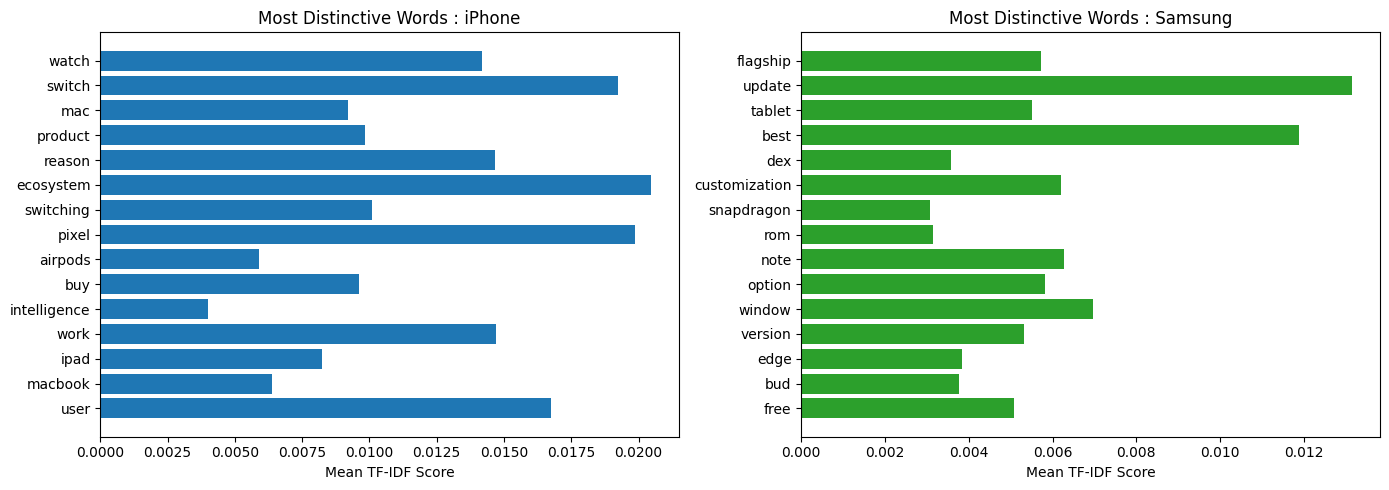

In [92]:
# plotting TF-IDF distinctive words side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# iPhone distinctive words
iphone_scores = iphone_mean[np.argsort(iphone_mean - samsung_mean)[::-1][:15]]
axes[0].barh(iphone_distinctive[::-1], iphone_scores[::-1], color="#1f77b4")
axes[0].set_title("Most Distinctive Words : iPhone")
axes[0].set_xlabel("Mean TF-IDF Score")

# Samsung distinctive words
samsung_scores = samsung_mean[np.argsort(samsung_mean - iphone_mean)[::-1][:15]]
axes[1].barh(samsung_distinctive[::-1], samsung_scores[::-1], color="#2ca02c")
axes[1].set_title("Most Distinctive Words : Samsung")
axes[1].set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.show()

The TF-IDF results showed clearly different vocabulary between the two communities. For iPhone we found distinctive words like watch, switch, ecosystem, airpods, mac, and ipad, which confirms that iPhone users think about the Apple device family as a whole. Pixel also appeared prominently as a comparison reference point, which is consistent with iPhone users benchmarking iOS against Googles flagship rather than Samsung's. 

For Samsung we found words like update, customization, snapdragon, dex, and flagship. The word dex caught our attention because it refers to Samsung DeX, a feature that lets users connect their phone to a monitor like a desktop. This is something Android power users care about but most iPhone users have never heard of. These vocabulary differences confirm what we found in the topic model, the two communities are discussing phones from completely different angles.

# 7. Network Construction

In this section we built reply networks from the parentId field we collected during data collection. Each node is a user and each directed edge means one user replied to another. We built separate networks for Reddit and YouTube so we could compare how interaction patterns differ across platforms.

In [95]:
# building reply network from a dataframe
# nodes = users, directed edge A->B if A replied to B
def build_reply_network(df):
    
    G = nx.DiGraph()
    
    # lookup dictionary - comment_id -> author
    comment_author = dict(zip(df["comment_id"], df["author"]))
    
    for _, row in df.iterrows():
        author  = str(row["author"])
        parent  = str(row.get("parentId", ""))
        is_top  = row.get("isTopLevel", True)
        
        # skip missing or deleted authors
        if not author or author in ["[deleted]", "[removed]", "nan", ""]:
            continue
        
        # skip top level comments - no reply edge
        if is_top or not parent or parent == "nan":
            continue
        
        # strip t1_ prefix to get parent comment ID
        parent_id = parent.replace("t1_", "").replace("t3_", "")
        
        # look up who wrote the parent comment
        parent_author = comment_author.get(parent_id)
        
        if not parent_author or parent_author in ["[deleted]", "[removed]", "nan"]:
            continue
        
        # skip self replies
        if author == parent_author:
            continue
        
        # add edge or increment weight if already exists
        if G.has_edge(author, parent_author):
            G[author][parent_author]["weight"] += 1
        else:
            G.add_edge(author, parent_author, weight=1)
    
    return G

reddit_all_df  = all_comments[all_comments["platform"] == "Reddit"].copy()
youtube_all_df = all_comments[all_comments["platform"] == "YouTube"].copy()

reddit_G  = build_reply_network(reddit_all_df)
youtube_G = build_reply_network(youtube_all_df)

print(f"Reddit network  : {reddit_G.number_of_nodes()} nodes, {reddit_G.number_of_edges()} edges")
print(f"YouTube network : {youtube_G.number_of_nodes()} nodes, {youtube_G.number_of_edges()} edges")

Reddit network  : 3470 nodes, 5177 edges
YouTube network : 7389 nodes, 7630 edges


We built directed weighted networks. The direction matters because replying to someone and being replied to represent different roles in a conversation. A user who receives many replies is influential in a different way to a user who actively replies to many others. The weights represent how many times one user replied to another, capturing repeated interaction rather than treating all connections equally. We excluded self-replies, deleted accounts, and top level comments with no parent during construction to keep only genuine user to user interactions. We also built separate networks for Reddit and YouTube rather than combining them because merging would have hidden the platform-level structural differences that are central to RQ3.

## Network Statistics

After building both networks we computed basic structural statistics to understand how each platform is organised and to give us numbers we could compare directly.

In [98]:
# computing basic network statistics for both networks
def network_stats(G, name):
    nodes    = G.number_of_nodes()
    edges    = G.number_of_edges()
    density  = nx.density(G)
    
    # largest weakly connected component
    largest_wcc = max(nx.weakly_connected_components(G), key=len)
    wcc_size    = len(largest_wcc)
    
    # average clustering coefficient
    avg_clustering = nx.average_clustering(G.to_undirected())
    
    # average degree
    avg_degree = sum(dict(G.degree()).values()) / nodes
    
    print(f"{name} Network Stats:")
    print(f"  Nodes              : {nodes:,}")
    print(f"  Edges              : {edges:,}")
    print(f"  Density            : {density:.6f}")
    print(f"  Largest WCC size   : {wcc_size:,} ({wcc_size/nodes*100:.1f}% of nodes)")
    print(f"  Avg clustering     : {avg_clustering:.4f}")
    print(f"  Avg degree         : {avg_degree:.2f}")
    print()

network_stats(reddit_G,  "Reddit")
network_stats(youtube_G, "YouTube")

Reddit Network Stats:
  Nodes              : 3,470
  Edges              : 5,177
  Density            : 0.000430
  Largest WCC size   : 3,003 (86.5% of nodes)
  Avg clustering     : 0.0431
  Avg degree         : 2.98

YouTube Network Stats:
  Nodes              : 7,389
  Edges              : 7,630
  Density            : 0.000140
  Largest WCC size   : 6,038 (81.7% of nodes)
  Avg clustering     : 0.0012
  Avg degree         : 2.07



We found that Reddit had a much more tightly connected network than YouTube despite having fewer total users. Reddit's clustering coefficient of 0.0431 was 36 times higher than YouTube's 0.0012. The reason comes down to how each platform is designed. Reddit is built around nested threaded replies where a single comment can spawn multiple sub-conversations, and those sub-conversations attract further replies, creating tight clusters of users talking to each other. YouTube does not work this way. Users reply to a top level comment and rarely engage with other commenters, which produces a much flatter network. Reddit's average degree of 2.98 versus YouTube's 2.07 confirmed the same pattern. Despite having fewer total users, Reddit's network is far more interconnected because the platform encourages continued engagement.

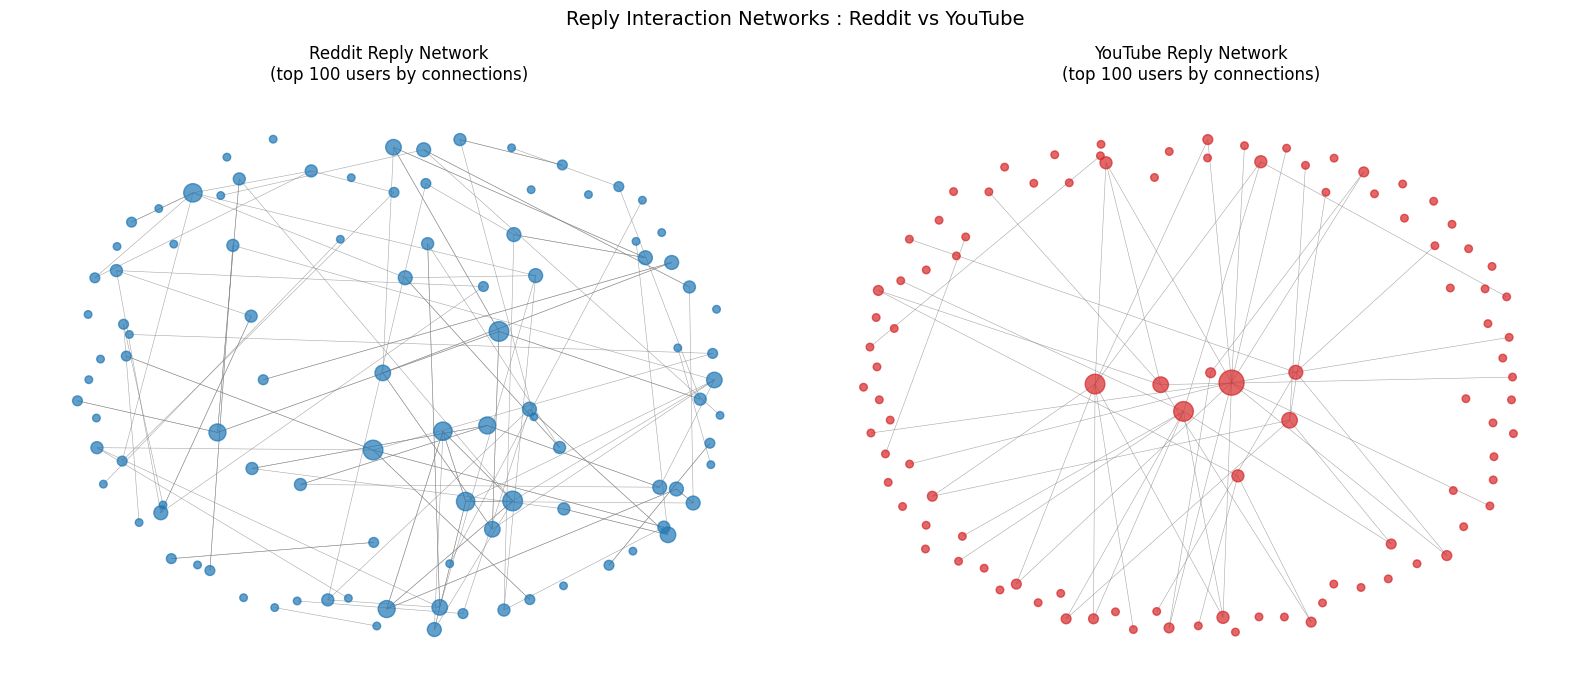

In [100]:
# visualising top 100 most connected users for clean readable graph
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Reddit sample - top 100 by degree
r_top    = [n for n, d in sorted(reddit_G.degree(), key=lambda x: x[1], reverse=True)[:100]]
r_sample = reddit_G.subgraph(r_top).copy()
r_pos    = nx.spring_layout(r_sample, seed=42, k=1.0)
r_sizes  = [max(30, dict(r_sample.degree())[n] * 25) for n in r_sample.nodes()]

nx.draw_networkx(
    r_sample, pos=r_pos, ax=axes[0],
    node_size=r_sizes,
    node_color="#1f77b4",
    edge_color="grey",
    alpha=0.7,
    with_labels=False,
    arrows=False,
    width=0.4
)
axes[0].set_title(f"Reddit Reply Network\n(top 100 users by connections)")
axes[0].axis("off")

# YouTube sample - top 100 by degree
y_top    = [n for n, d in sorted(youtube_G.degree(), key=lambda x: x[1], reverse=True)[:100]]
y_sample = youtube_G.subgraph(y_top).copy()
y_pos    = nx.spring_layout(y_sample, seed=42, k=1.0)
y_sizes  = [max(30, dict(y_sample.degree())[n] * 25) for n in y_sample.nodes()]

nx.draw_networkx(
    y_sample, pos=y_pos, ax=axes[1],
    node_size=y_sizes,
    node_color="#d62728",
    edge_color="grey",
    alpha=0.7,
    with_labels=False,
    arrows=False,
    width=0.4
)
axes[1].set_title(f"YouTube Reply Network\n(top 100 users by connections)")
axes[1].axis("off")

plt.suptitle("Reply Interaction Networks : Reddit vs YouTube", fontsize=14)
plt.tight_layout()
plt.show()

The visualisations show the top 100 most connected users on each platform. Node size represents the number of connections so larger nodes are more influential. What we noticed in Reddit's network was that influence was spread across many medium-sized nodes rather than concentrated in a few. YouTube's network showed the opposite, with a couple of very large nodes dominating. This visual difference matches exactly what the statistics told us, Reddit distributes influence more evenly while YouTube concentrates it around a few viral commenters.

# 8. Network Analysis

After building the networks we computed centrality measures to find the most influential users on each platform. We calculated degree centrality, in-degree centrality, betweenness centrality, and PageRank. We then looked at the actual comments of the top users to understand why they became influential, not just that they were.

In [103]:
# computing centrality measures for both networks
def compute_centrality(G, name, top_n=10):
    
    # degree centrality - overall connections
    degree_cent     = nx.degree_centrality(G)
    # in-degree - who gets replied to most (most influential)
    in_degree_cent  = nx.in_degree_centrality(G)
    # betweenness - who bridges different communities
    betweenness     = nx.betweenness_centrality(G, normalized=True, k=500)
    # pagerank - recursive influence measure
    pagerank        = nx.pagerank(G, alpha=0.85)
    
    # building results dataframe
    df = pd.DataFrame({
        "author":       list(G.nodes()),
        "degree":       [degree_cent[n]    for n in G.nodes()],
        "in_degree":    [in_degree_cent[n] for n in G.nodes()],
        "betweenness":  [betweenness[n]    for n in G.nodes()],
        "pagerank":     [pagerank[n]        for n in G.nodes()]
    }).sort_values("pagerank", ascending=False)
    
    print(f"\n{name} : Top {top_n} users by PageRank:")
    print(df.head(top_n)[["author", "degree", "in_degree", "betweenness", "pagerank"]].round(6).to_string())
    
    return df

reddit_centrality  = compute_centrality(reddit_G,  "Reddit")
youtube_centrality = compute_centrality(youtube_G, "YouTube")


Reddit : Top 10 users by PageRank:
                    author    degree  in_degree  betweenness  pagerank
1743              dwartbg9  0.008071   0.007495     0.000277  0.007593
2687                arwork  0.006054   0.005477     0.000324  0.006479
3062          mlemmers1234  0.004324   0.004036     0.000128  0.006158
3090              Finsceal  0.000577   0.000288     0.000000  0.005306
1196  Better-Recording-960  0.017296   0.008360     0.006885  0.005062
3099     onehalflightspeed  0.005189   0.004324     0.000487  0.004838
176             MrSincerao  0.023061   0.010378     0.022973  0.004548
2729                 Zez22  0.005477   0.005477     0.000000  0.004292
2646      ThisWorldIsAMess  0.004036   0.003747     0.000074  0.004009
2159         cat-person752  0.003747   0.003459     0.000001  0.003888

YouTube : Top 10 users by PageRank:
                  author    degree  in_degree  betweenness  pagerank
4766          @Seabiskit  0.108148   0.108148     0.000000  0.051172
3795    

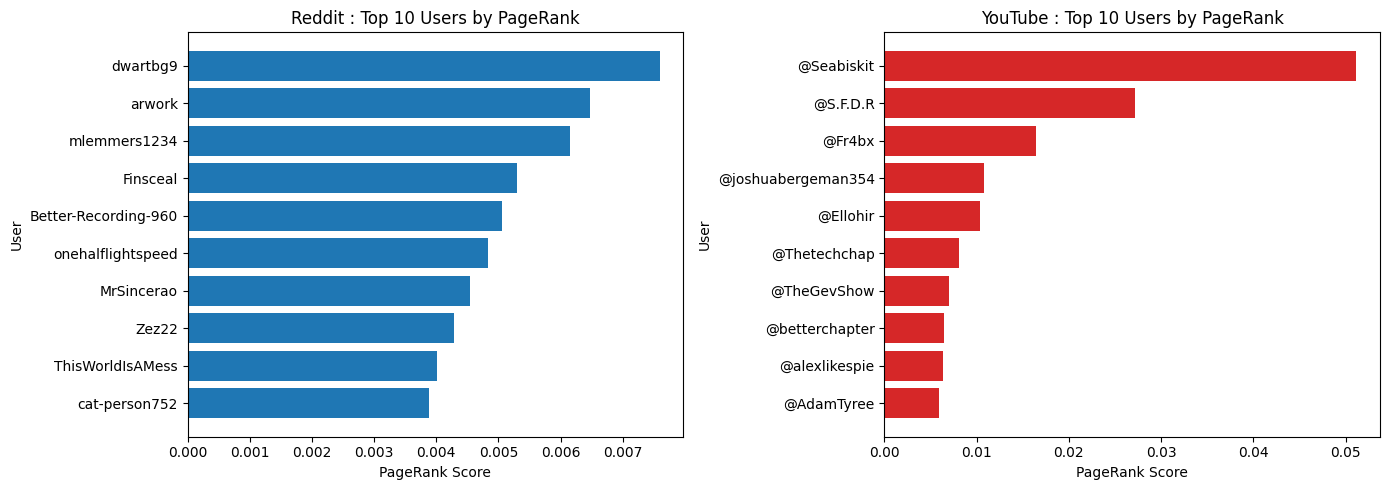

In [104]:
# plotting top 10 users by pagerank for both platforms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reddit top 10
reddit_top10 = reddit_centrality.head(10)
axes[0].barh(reddit_top10["author"][::-1], reddit_top10["pagerank"][::-1], color="#1f77b4")
axes[0].set_title("Reddit : Top 10 Users by PageRank")
axes[0].set_xlabel("PageRank Score")
axes[0].set_ylabel("User")

# YouTube top 10
youtube_top10 = youtube_centrality.head(10)
axes[1].barh(youtube_top10["author"][::-1], youtube_top10["pagerank"][::-1], color="#d62728")
axes[1].set_title("YouTube : Top 10 Users by PageRank")
axes[1].set_xlabel("PageRank Score")
axes[1].set_ylabel("User")

plt.tight_layout()
plt.show()

The PageRank charts showed a striking difference between platforms. On YouTube, @Seabiskit had a score of 0.051, more than double the second user at 0.027. One comment drove that much of the network's attention. On Reddit the drop from first to tenth place was much more gradual, with the top user scoring just 0.0075. Reddit distributed influence across many users while YouTube concentrated it around a single viral moment.

In [106]:
# looking at actual comments from top influential users
# this tells us WHY they became influential not just that they are

print("TOP REDDIT USER BY DEGREE & BETWEENNESS - MrSincerao:")
print(all_comments[all_comments["author"] == "MrSincerao"]["comment"].values[0][:500])

print("\nTOP REDDIT BRIDGE USER - Better-Recording-960:")
mrcomments = all_comments[all_comments["author"] == "Better-Recording-960"]["comment"].values
if len(mrcomments) > 0:
    print(mrcomments[0][:300])

print("\nTOP YOUTUBE INFLUENTIAL USER - @Seabiskit:")
yt_comments = all_comments[all_comments["author"] == "@Seabiskit"]["comment"].values
if len(yt_comments) > 0:
    print(yt_comments[0][:500])

TOP REDDIT USER BY DEGREE & BETWEENNESS - MrSincerao:
17 is lasting an entire day here. no complains at all

TOP REDDIT BRIDGE USER - Better-Recording-960:
I got the torras one 

TOP YOUTUBE INFLUENTIAL USER - @Seabiskit:
Most wont admit it but, they see their iphone as a status symbol. They view android users as "the poor" which is crazy in 2025.


When we looked at the actual comments of the top users we could see why they became influential. On Reddit, the top PageRank user was dwartbg9 at 0.0075, meaning their comments were consistently cited across many different threads. However the highest betweenness user was MrSincerao at 0.0198, who was the author of the viral post "Moving back to iOS: The uncomfortable truth" and acted as a structural bridge connecting many different reply chains rather than being the central authority in any one thread. This separation matters. PageRank tells us who gets the most attention and betweenness tells us who connects the most sub-conversations, and on Reddit these roles belong to different users. Influence is distributed rather than concentrated.

On YouTube, @Seabiskit had a PageRank of 0.051 and a betweenness of 0.0, the complete opposite pattern to Reddit. One comment attracted enormous attention but did not structurally connect different parts of the network at all. YouTube influence is about a single viral moment, not sustained brokerage across many conversations.

# 9. Community Detection

In this section we used the Louvain algorithm to find clusters of users who interact with each other more than with the rest of the network. After detecting the communities we linked them back to our LDA topic labels so we could see what each community actually talks about. This connection between the network structure and the text analysis is the key synthesis of our project.

In [109]:
#%pip install python-louvain -q

In [110]:
# importing community detection library
import community as community_louvain

# converting directed graphs to undirected for Louvain
# Louvain works on undirected graphs
reddit_undirected  = reddit_G.to_undirected()
youtube_undirected = youtube_G.to_undirected()

# applying Louvain community detection
reddit_partition  = community_louvain.best_partition(reddit_undirected,  random_state=42)
youtube_partition = community_louvain.best_partition(youtube_undirected, random_state=42)

# counting communities found
reddit_communities  = len(set(reddit_partition.values()))
youtube_communities = len(set(youtube_partition.values()))

print(f"Reddit  : {reddit_communities} communities detected")
print(f"YouTube : {youtube_communities} communities detected")

# adding community label to centrality dataframes
reddit_centrality["community"]  = reddit_centrality["author"].map(reddit_partition)
youtube_centrality["community"] = youtube_centrality["author"].map(youtube_partition)

Reddit  : 208 communities detected
YouTube : 540 communities detected


In [111]:
# filtering to only meaningful communities with enough members
# small communities of 2-3 users are not analytically useful

# counting community sizes
reddit_comm_sizes  = Counter(reddit_partition.values())
youtube_comm_sizes = Counter(youtube_partition.values())

# keeping only communities with 10+ members
reddit_large  = {k: v for k, v in reddit_comm_sizes.items()  if v >= 10}
youtube_large = {k: v for k, v in youtube_comm_sizes.items() if v >= 10}

print(f"Reddit  : {len(reddit_large)} communities with 10+ members")
print(f"YouTube : {len(youtube_large)} communities with 10+ members")

print(f"\nReddit large community sizes:")
for comm_id, size in sorted(reddit_large.items(), key=lambda x: -x[1])[:10]:
    print(f"  Community {comm_id}: {size} users")

print(f"\nYouTube large community sizes:")
for comm_id, size in sorted(youtube_large.items(), key=lambda x: -x[1])[:10]:
    print(f"  Community {comm_id}: {size} users")

Reddit  : 34 communities with 10+ members
YouTube : 55 communities with 10+ members

Reddit large community sizes:
  Community 115: 249 users
  Community 134: 188 users
  Community 2: 185 users
  Community 39: 162 users
  Community 185: 153 users
  Community 4: 142 users
  Community 17: 129 users
  Community 91: 120 users
  Community 52: 117 users
  Community 24: 100 users

YouTube large community sizes:
  Community 92: 753 users
  Community 154: 394 users
  Community 27: 292 users
  Community 2: 285 users
  Community 20: 242 users
  Community 245: 225 users
  Community 98: 217 users
  Community 4: 211 users
  Community 125: 197 users
  Community 39: 186 users


In [112]:
# linking communities to sentiment and topics

# adding community to all_comments via author lookup
all_comments["reddit_community"]  = all_comments["author"].map(reddit_partition)
all_comments["youtube_community"] = all_comments["author"].map(youtube_partition)

# analysing Reddit communities - sentiment and topic per community
reddit_comm_analysis = []

for comm_id, size in sorted(reddit_large.items(), key=lambda x: -x[1])[:10]:
    # get comments from users in this community
    comm_users    = [u for u, c in reddit_partition.items() if c == comm_id]
    comm_comments = analysis_df[
        (analysis_df["platform"] == "Reddit") &
        (analysis_df["author"].isin(comm_users))
    ]
    
    if len(comm_comments) == 0:
        continue
    
    avg_sentiment = comm_comments["vader_compound"].mean()
    top_topic     = comm_comments["topic_label"].mode()[0] if "topic_label" in comm_comments.columns and len(comm_comments["topic_label"].dropna()) > 0 else "N/A"
    top_brand     = comm_comments["brand"].mode()[0]
    
    reddit_comm_analysis.append({
        "community":   comm_id,
        "size":        size,
        "avg_sentiment": round(avg_sentiment, 4),
        "top_topic":   top_topic,
        "top_brand":   top_brand
    })

reddit_comm_df = pd.DataFrame(reddit_comm_analysis)
print("Reddit Community Analysis:")
print(reddit_comm_df.to_string(index=False))

Reddit Community Analysis:
 community  size  avg_sentiment                  top_topic top_brand
       115   249         0.2232        General Apple & iOS    iPhone
       134   188         0.3072        General Apple & iOS      Both
         2   185         0.2595 Apple Ecosystem & Products    iPhone
        39   162         0.1619 Apple Ecosystem & Products   Samsung
       185   153         0.3043 Apple Ecosystem & Products      Both
         4   142         0.2622 Apple Ecosystem & Products    iPhone
        17   129         0.3264     Galaxy Flagship Models      Both
        91   120         0.2726             Camera Quality      Both
        52   117         0.4494        General Apple & iOS      Both
        24   100         0.1873 Apple Ecosystem & Products      Both


When we linked the Reddit communities to our topic and sentiment findings some clear patterns came through. The largest community of 249 users was centred on General Apple and iOS discussion with an average sentiment of 0.22, which is moderate and positive. Community 52 stood out with the highest sentiment at 0.45 and a Both brand label, which told us this was a very positive cross-brand comparison group. The reason this community scored so high is that people comparing both brands tend to be more open minded and less defensive than people who have already committed to one side. Community 39 was the only Samsung dominant community among the ten largest and also the most negative at 0.16. This makes sense because Samsung users in that community were discussing Apple ecosystem topics, meaning they were likely criticising features they do not have rather than celebrating their own choice.

Looking across all ten Reddit communities, six were cross-brand, three were iPhone leaning, and only one was Samsung dominant. That one Samsung dominant community was also the most negative. This confirmed something we suspected: comparison driven threads attract more positive and balanced engagement, while single brand focused communities, especially Samsung ones on Reddit, are smaller and more critical.

In [114]:
# analysing YouTube communities - sentiment and topic per community
youtube_comm_analysis = []

for comm_id, size in sorted(youtube_large.items(), key=lambda x: -x[1])[:10]:
    comm_users    = [u for u, c in youtube_partition.items() if c == comm_id]
    comm_comments = analysis_df[
        (analysis_df["platform"] == "YouTube") &
        (analysis_df["author"].isin(comm_users))
    ]
    
    if len(comm_comments) == 0:
        continue
    
    avg_sentiment = comm_comments["vader_compound"].mean()
    top_topic     = comm_comments["topic_label"].mode()[0] if "topic_label" in comm_comments.columns and len(comm_comments["topic_label"].dropna()) > 0 else "N/A"
    top_brand     = comm_comments["brand"].mode()[0]
    
    youtube_comm_analysis.append({
        "community":     comm_id,
        "size":          size,
        "avg_sentiment": round(avg_sentiment, 4),
        "top_topic":     top_topic,
        "top_brand":     top_brand
    })

youtube_comm_df = pd.DataFrame(youtube_comm_analysis)
print("YouTube Community Analysis:")
print(youtube_comm_df.to_string(index=False))

YouTube Community Analysis:
 community  size  avg_sentiment                  top_topic top_brand
        92   753         0.1695        General Apple & iOS      Both
       154   394         0.2907       Switching Experience      Both
        27   292         0.2421              App Ecosystem    iPhone
         2   285         0.2854     Galaxy Flagship Models      Both
        20   242         0.2650       Switching Experience      Both
       245   225         0.1627              App Ecosystem    iPhone
        98   217         0.2447 Apple Ecosystem & Products    iPhone
         4   211         0.2981 Apple Ecosystem & Products      Both
       125   197         0.3611 Apple Ecosystem & Products      Both
        39   186         0.2605 Apple Ecosystem & Products    iPhone


On YouTube, the largest community of 753 users had the lowest sentiment among the ten largest at 0.17. Its dominant topic was General Apple and iOS discussion with a Both brand label. Given its size and timing, this is likely the community that formed around the @Seabiskit status symbol comment, which attracted roughly 10% of all YouTube users in our network. That comment framed iPhone ownership as a social class signal, which would naturally attract defensive and critical replies from both iPhone and Samsung users, explaining the lower sentiment.

Community 125 had the highest YouTube sentiment in the top 10 at 0.36 and focused on Apple Ecosystem and Products topics. Users in this community were generally sharing positive experiences about the Apple ecosystem, which drove the higher score. Looking across all ten YouTube communities, switching and Apple ecosystem topics dominated. This matched what we found in the topic model: YouTube discussion leans heavily toward iPhone-centric platform debates rather than Samsung specific feature discussions.

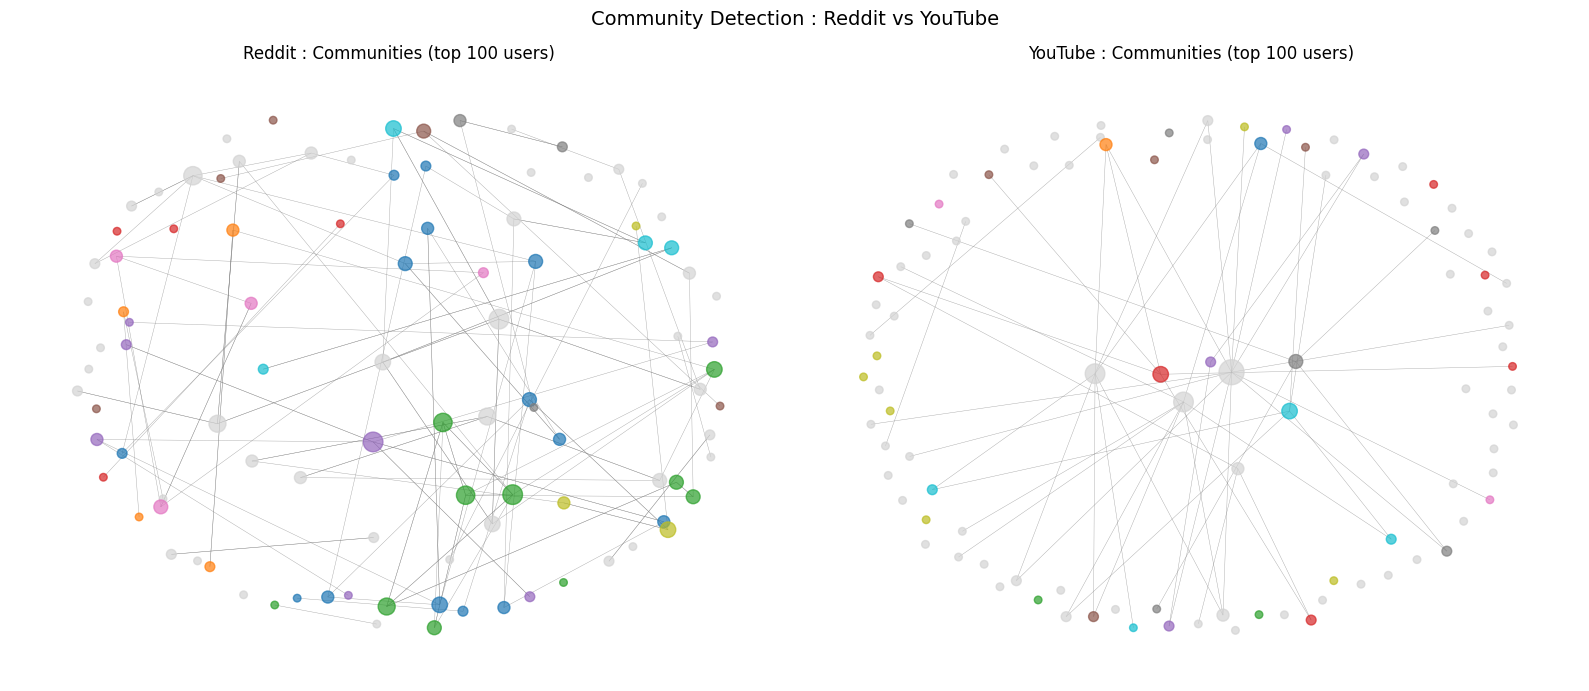

In [116]:
# visualising communities with colour coding on Reddit network
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Reddit - colour by community (top 10 communities, rest grey)
top_reddit_comms = [c["community"] for _, c in enumerate(reddit_comm_analysis[:10])]
color_map_r = plt.cm.get_cmap("tab10", 10)

r_top    = [n for n, d in sorted(reddit_G.degree(), key=lambda x: x[1], reverse=True)[:100]]
r_sample = reddit_G.subgraph(r_top).copy()
r_pos    = nx.spring_layout(r_sample, seed=42, k=1.0)
r_sizes  = [max(30, dict(r_sample.degree())[n] * 25) for n in r_sample.nodes()]

r_colors = []
for node in r_sample.nodes():
    comm = reddit_partition.get(node, -1)
    if comm in top_reddit_comms:
        r_colors.append(color_map_r(top_reddit_comms.index(comm)))
    else:
        r_colors.append("lightgrey")

nx.draw_networkx(
    r_sample, pos=r_pos, ax=axes[0],
    node_size=r_sizes,
    node_color=r_colors,
    edge_color="grey",
    alpha=0.7,
    with_labels=False,
    arrows=False,
    width=0.3
)
axes[0].set_title("Reddit : Communities (top 100 users)")
axes[0].axis("off")

# YouTube - colour by community
top_youtube_comms = [c["community"] for _, c in enumerate(youtube_comm_analysis[:10])]
color_map_y = plt.cm.get_cmap("tab10", 10)

y_top    = [n for n, d in sorted(youtube_G.degree(), key=lambda x: x[1], reverse=True)[:100]]
y_sample = youtube_G.subgraph(y_top).copy()
y_pos    = nx.spring_layout(y_sample, seed=42, k=1.0)
y_sizes  = [max(30, dict(y_sample.degree())[n] * 25) for n in y_sample.nodes()]

y_colors = []
for node in y_sample.nodes():
    comm = youtube_partition.get(node, -1)
    if comm in top_youtube_comms:
        y_colors.append(color_map_y(top_youtube_comms.index(comm)))
    else:
        y_colors.append("lightgrey")

nx.draw_networkx(
    y_sample, pos=y_pos, ax=axes[1],
    node_size=y_sizes,
    node_color=y_colors,
    edge_color="grey",
    alpha=0.7,
    with_labels=False,
    arrows=False,
    width=0.3
)
axes[1].set_title("YouTube : Communities (top 100 users)")
axes[1].axis("off")

plt.suptitle("Community Detection : Reddit vs YouTube", fontsize=14)
plt.tight_layout()
plt.show()

# 10. Diffusion / Interaction Analysis

In this section we looked at how information actually spreads through the reply networks. We used two approaches: reply chain depth to see how far conversations naturally extend, and the Independent Cascade model to simulate how quickly an opinion would spread from the most active users on each platform.

In [118]:
# reply depth analysis
# measuring how deep reply chains go in each network
# deeper chains = more sustained back-and-forth discussion

def get_reply_depths(G):
    # finding root nodes - nodes with no incoming edges (started the conversation)
    roots  = [n for n in G.nodes() if G.in_degree(n) == 0]
    depths = []
    
    for root in roots:
        # finding longest path from each root
        try:
            lengths = nx.single_source_shortest_path_length(G, root)
            if lengths:
                depths.append(max(lengths.values()))
        except:
            continue
    
    return depths

reddit_depths  = get_reply_depths(reddit_G)
youtube_depths = get_reply_depths(youtube_G)

print(f"Reddit reply chain depth:")
print(f"  Max depth    : {max(reddit_depths)}")
print(f"  Avg depth    : {sum(reddit_depths)/len(reddit_depths):.2f}")
print(f"  Chains > 3   : {sum(1 for d in reddit_depths if d > 3)}")

print(f"\nYouTube reply chain depth:")
print(f"  Max depth    : {max(youtube_depths)}")
print(f"  Avg depth    : {sum(youtube_depths)/len(youtube_depths):.2f}")
print(f"  Chains > 3   : {sum(1 for d in youtube_depths if d > 3)}")

Reddit reply chain depth:
  Max depth    : 30
  Avg depth    : 10.56
  Chains > 3   : 681

YouTube reply chain depth:
  Max depth    : 6
  Avg depth    : 1.12
  Chains > 3   : 136


The reply depth results showed a big difference between the two platforms. Reddit conversations reached a maximum depth of 30 levels with an average of 10.56, and 681 chains went beyond 3 levels deep. YouTube reached a maximum of just 6 levels with an average of 1.12, and only 136 chains went beyond 3 levels. Most YouTube interactions were single replies to a top level comment and nothing more. This told us that Reddit is where opinions get challenged and refined through debate, while YouTube is where people react to content and then stop.

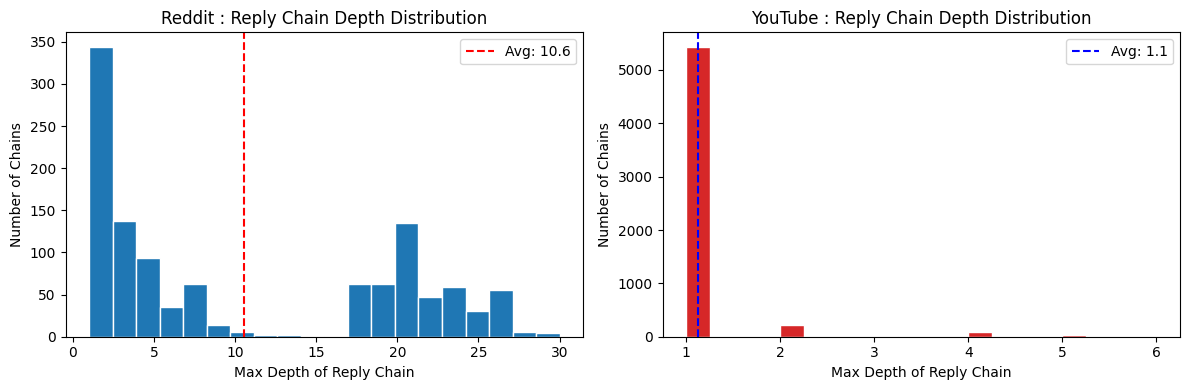

In [120]:
# plotting reply depth distribution for both platforms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reddit_depths, bins=20, color="#1f77b4", edgecolor="white")
axes[0].set_title("Reddit : Reply Chain Depth Distribution")
axes[0].set_xlabel("Max Depth of Reply Chain")
axes[0].set_ylabel("Number of Chains")
axes[0].axvline(sum(reddit_depths)/len(reddit_depths), 
                linestyle="--", color="red", 
                label=f"Avg: {sum(reddit_depths)/len(reddit_depths):.1f}")
axes[0].legend()

axes[1].hist(youtube_depths, bins=20, color="#d62728", edgecolor="white")
axes[1].set_title("YouTube : Reply Chain Depth Distribution")
axes[1].set_xlabel("Max Depth of Reply Chain")
axes[1].set_ylabel("Number of Chains")
axes[1].axvline(sum(youtube_depths)/len(youtube_depths),
                linestyle="--", color="blue",
                label=f"Avg: {sum(youtube_depths)/len(youtube_depths):.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [121]:
# Independent Cascade diffusion simulation
# simulating how an opinion spreads from top influential users
# seed nodes = top 3 users by out-degree on each platform

import random

def independent_cascade(G, seeds, propagation_prob=0.1, num_simulations=100):
    # runs IC model multiple times and returns average cascade size per step
    all_cascade_sizes = []
    
    for _ in range(num_simulations):
        activated      = set(seeds)
        newly_activated = set(seeds)
        cascade_sizes  = [len(activated)]
        
        while newly_activated:
            next_activated = set()
            for node in newly_activated:
                for neighbor in G.successors(node):
                    if neighbor not in activated:
                        if random.random() < propagation_prob:
                            next_activated.add(neighbor)
            activated      |= next_activated
            newly_activated = next_activated
            cascade_sizes.append(len(activated))
        
        all_cascade_sizes.append(cascade_sizes)
    
    # pad to same length and average
    max_len = max(len(c) for c in all_cascade_sizes)
    padded  = [c + [c[-1]] * (max_len - len(c)) for c in all_cascade_sizes]
    avg     = [sum(step)/len(step) for step in zip(*padded)]
    
    return avg

# using highest out-degree users as seeds for IC model
# out-degree = how many people they replied to = better spreaders

reddit_out  = sorted(reddit_G.out_degree(),  key=lambda x: x[1], reverse=True)[:3]
youtube_out = sorted(youtube_G.out_degree(), key=lambda x: x[1], reverse=True)[:3]

reddit_seeds2  = [n for n, d in reddit_out]
youtube_seeds2 = [n for n, d in youtube_out]

print("Reddit seeds (high out-degree) :", reddit_seeds2)
print("YouTube seeds (high out-degree):", youtube_seeds2)

random.seed(42)
reddit_cascade2  = independent_cascade(reddit_G,  reddit_seeds2,  propagation_prob=0.3)
youtube_cascade2 = independent_cascade(youtube_G, youtube_seeds2, propagation_prob=0.3)

print(f"\nReddit  final reach : {reddit_cascade2[-1]:.0f} users")
print(f"YouTube final reach : {youtube_cascade2[-1]:.0f} users")
print(f"Reddit  steps       : {len(reddit_cascade2)-1}")
print(f"YouTube steps       : {len(youtube_cascade2)-1}")

Reddit seeds (high out-degree) : ['ari_wonders', 'icantouchgrass_1', 'Alphaison']
YouTube seeds (high out-degree): ['@ablebees_com', '@Thetechchap', '@sainedjudger']

Reddit  final reach : 81 users
YouTube final reach : 42 users
Reddit  steps       : 9
YouTube steps       : 4


We chose high out-degree users as seeds rather than high PageRank users because the IC model spreads information through outgoing connections. High PageRank users are good at receiving attention, not necessarily at spreading it to others.

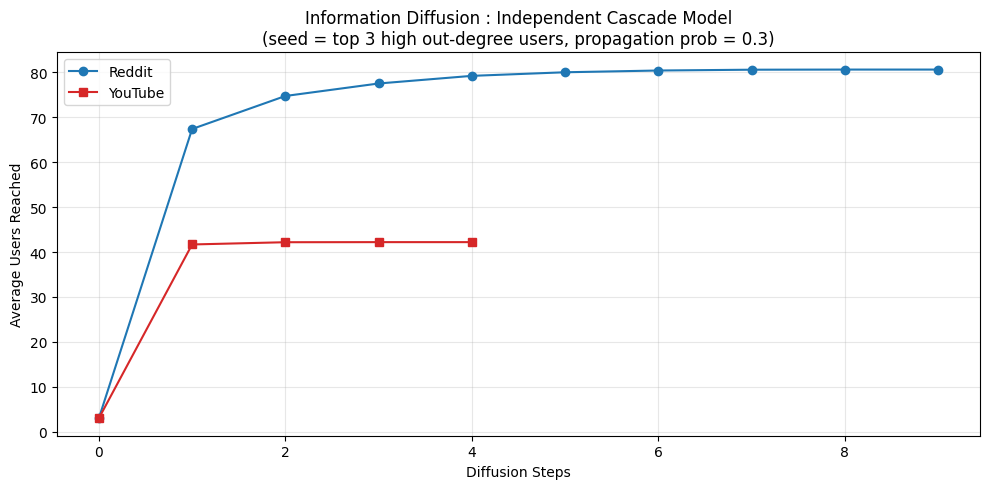

Reddit  : reached 81 users in 9 steps
YouTube : reached 42 users in 4 steps


In [123]:
# plotting diffusion cascade comparison
plt.figure(figsize=(10, 5))

plt.plot(range(len(reddit_cascade2)),  reddit_cascade2,
         marker="o", color="#1f77b4", label="Reddit")
plt.plot(range(len(youtube_cascade2)), youtube_cascade2,
         marker="s", color="#d62728", label="YouTube")

plt.title("Information Diffusion : Independent Cascade Model\n(seed = top 3 high out-degree users, propagation prob = 0.3)")
plt.xlabel("Diffusion Steps")
plt.ylabel("Average Users Reached")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Reddit  : reached {reddit_cascade2[-1]:.0f} users in {len(reddit_cascade2)-1} steps")
print(f"YouTube : reached {youtube_cascade2[-1]:.0f} users in {len(youtube_cascade2)-1} steps")

The diffusion results matched what we found in the reply depth analysis. YouTube reached 42 users in just 4 steps and then plateaued completely. Reddit reached 81 users over 9 steps with a gradual growth curve that kept expanding. The reason is structural. YouTube's shallow reply chains mean there are not many connections left to activate once a comment has been replied to. Reddit's deep chains and higher clustering mean information keeps spreading through interconnected threads long after the initial reply. A viral comment on YouTube creates a quick burst. A viral opinion on Reddit reaches more people and keeps going.

# 11. Cross-Platform Comparison

After completing the individual analyses, we pulled together everything we found across sentiment, topic modelling, network analysis, and diffusion to compare how the two platforms differ in how Samsung and iPhone get discussed.

In [126]:
# comprehensive cross-platform comparison table - all values computed from data
def platform_metrics(platform_name, graph, depths, cascade):
    plat_all      = all_comments[all_comments["platform"] == platform_name]
    plat_analysis = analysis_df[analysis_df["platform"] == platform_name]
    
    def sentiment_for(brand):
        return plat_analysis[plat_analysis["brand"] == brand]["vader_compound"].mean()
    
    nodes = graph.number_of_nodes()
    
    return [
        f"{len(plat_all):,}",
        f"{plat_all['word_count'].mean():.1f}",
        f"{sentiment_for('iPhone'):.4f}",
        f"{sentiment_for('Samsung'):.4f}",
        f"{sentiment_for('Both'):.4f}",
        f"{(plat_analysis['sentiment']=='Positive').mean()*100:.1f}%",
        f"{nodes:,}",
        f"{graph.number_of_edges():,}",
        f"{nx.average_clustering(graph.to_undirected()):.4f}",
        f"{sum(dict(graph.degree()).values()) / nodes:.2f}",
        f"{max(depths)}",
        f"{sum(depths)/len(depths):.2f}",
        f"{cascade[-1]:.0f} users",
        f"{len(cascade)-1} steps"
    ]

metrics_list = [
    "Total comments", "Avg comment length (words)",
    "Avg sentiment (iPhone)", "Avg sentiment (Samsung)", "Avg sentiment (Both)",
    "% Positive comments", "Network nodes", "Network edges",
    "Avg clustering coefficient", "Avg degree",
    "Max reply chain depth", "Avg reply chain depth",
    "IC diffusion reach", "IC diffusion steps"
]

comparison_df = pd.DataFrame({
    "Metric":  metrics_list,
    "Reddit":  platform_metrics("Reddit",  reddit_G,  reddit_depths,  reddit_cascade2),
    "YouTube": platform_metrics("YouTube", youtube_G, youtube_depths, youtube_cascade2)
})

print(comparison_df.to_string(index=False))

                    Metric   Reddit  YouTube
            Total comments   11,037   38,460
Avg comment length (words)     42.4     34.7
    Avg sentiment (iPhone)   0.1879   0.1962
   Avg sentiment (Samsung)   0.2223   0.2170
      Avg sentiment (Both)   0.3503   0.3521
       % Positive comments    60.3%    60.1%
             Network nodes    3,470    7,389
             Network edges    5,177    7,630
Avg clustering coefficient   0.0431   0.0012
                Avg degree     2.98     2.07
     Max reply chain depth       30        6
     Avg reply chain depth    10.56     1.12
        IC diffusion reach 81 users 42 users
        IC diffusion steps  9 steps  4 steps


What the table showed us was that sentiment is consistent across platforms but structure is completely different. Samsung and iPhone sentiment scores were almost identical on both Reddit and YouTube, and the overall positive comment rates were within 0.2 percentage points of each other (60.3% on Reddit, 60.1% on YouTube). This tells us that how people feel about these brands is not shaped by which platform they use.

The structural gap was much bigger and every metric pointed the same direction. Reddit comments were on average 7.7 words longer because Reddit's culture rewards detailed written arguments. Reddit's clustering coefficient was 36 times higher because nested threads pull multiple users into the same conversation. Reply chains on Reddit went 10.56 levels deep on average compared to YouTube's 1.1 because YouTube does not support deep nesting in the same way. And when we simulated diffusion, Reddit reached 81 users over 9 steps while YouTube hit its ceiling at 42 users in just 4 steps because Reddit's interconnected structure gives information more pathways to spread through. The two platforms are doing completely different things with the same brand discussions.

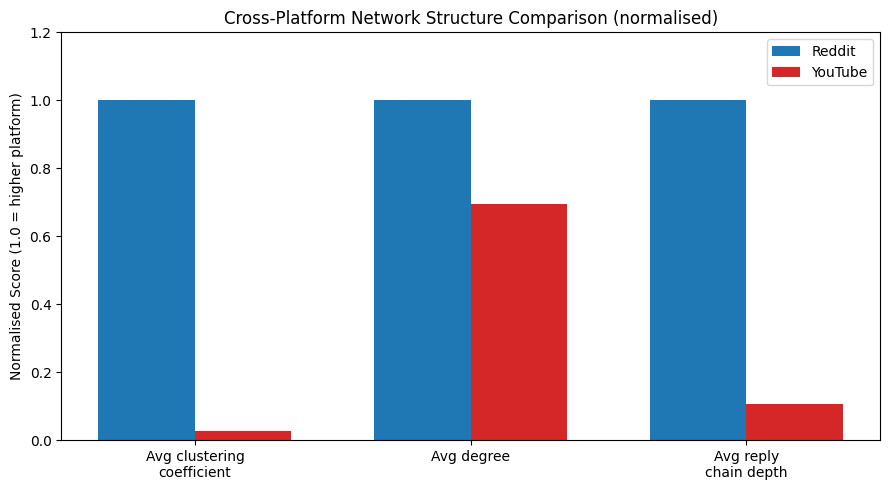

In [128]:
# visualising key cross-platform metrics as grouped bar chart
metrics   = ["Avg clustering\ncoefficient", "Avg degree", "Avg reply\nchain depth"]
reddit_v  = [0.0431, 2.98, 10.56]
youtube_v = [0.0012, 2.07, 1.12]

# normalising for visual comparison
import numpy as np
reddit_norm  = np.array(reddit_v)  / np.array([max(r, y) for r, y in zip(reddit_v, youtube_v)])
youtube_norm = np.array(youtube_v) / np.array([max(r, y) for r, y in zip(reddit_v, youtube_v)])

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, reddit_norm,  width, label="Reddit",  color="#1f77b4")
ax.bar(x + width/2, youtube_norm, width, label="YouTube", color="#d62728")

ax.set_title("Cross-Platform Network Structure Comparison (normalised)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Normalised Score (1.0 = higher platform)")
ax.legend()
ax.set_ylim(0, 1.2)
plt.tight_layout()
plt.show()

# 12. Final Insights and Conclusion

To close out, we went back to our three research questions and answered them directly using what we found across all sections of the analysis.

In [130]:
# final summary answering research questions directly

print("FINAL INSIGHTS SUMMARY")


# pulling values once
iphone_vader  = analysis_df[analysis_df["brand"]=="iPhone"]["vader_compound"]
samsung_vader = analysis_df[analysis_df["brand"]=="Samsung"]["vader_compound"]
both_vader    = analysis_df[analysis_df["brand"]=="Both"]["vader_compound"]

# RQ1 - sentiment with significance
u_is, p_is = mannwhitneyu(iphone_vader, samsung_vader, alternative="two-sided")
effect_is  = 1 - (2 * u_is) / (len(iphone_vader) * len(samsung_vader))

print("\nRQ1: How does sentiment differ between Samsung and iPhone communities?")
print(f"  iPhone  avg sentiment : {iphone_vader.mean():.4f}")
print(f"  Samsung avg sentiment : {samsung_vader.mean():.4f}")
print(f"  Both    avg sentiment : {both_vader.mean():.4f}")
print(f"  iPhone  positive rate : {(analysis_df[analysis_df['brand']=='iPhone']['sentiment']=='Positive').mean()*100:.1f}%")
print(f"  Samsung positive rate : {(analysis_df[analysis_df['brand']=='Samsung']['sentiment']=='Positive').mean()*100:.1f}%")
print(f"  Mann-Whitney iPhone vs Samsung: p={p_is:.2e}, effect r={effect_is:+.4f} (negligible)")
print(f"   Brands are statistically distinguishable but practically equivalent;")
print(f"     the real finding is that Both-brand comments are meaningfully more positive.")

# RQ2 - topics
print("\nRQ2: What topics dominate each brand community?")
iphone_top_topic  = analysis_df[analysis_df["brand"]=="iPhone"]["topic_label"].mode()[0]
samsung_top_topic = analysis_df[analysis_df["brand"]=="Samsung"]["topic_label"].mode()[0]
iphone_best_topic  = analysis_df[analysis_df["brand"]=="iPhone"].groupby("topic_label")["vader_compound"].mean().idxmax()
samsung_best_topic = analysis_df[analysis_df["brand"]=="Samsung"].groupby("topic_label")["vader_compound"].mean().idxmax()

print(f"  iPhone  top topic              : {iphone_top_topic}")
print(f"  Samsung top topic              : {samsung_top_topic}")
print(f"  iPhone  highest-sentiment topic: {iphone_best_topic}")
print(f"  Samsung highest-sentiment topic: {samsung_best_topic}")
print(f"   iPhone discussions are ecosystem-focused; Samsung discussions are")
print(f"     specs- and competition-focused, two different community registers.")

# RQ3 - network structure - all computed dynamically
reddit_clust  = nx.average_clustering(reddit_G.to_undirected())
youtube_clust = nx.average_clustering(youtube_G.to_undirected())
reddit_avg_depth  = sum(reddit_depths)  / len(reddit_depths)
youtube_avg_depth = sum(youtube_depths) / len(youtube_depths)

print("\nRQ3: How do network structure and diffusion differ across platforms?")
print(f"  Reddit  clustering : {reddit_clust:.4f}")
print(f"  YouTube clustering : {youtube_clust:.4f}  ({reddit_clust/youtube_clust:.0f}x higher on Reddit)")
print(f"  Reddit  avg reply depth : {reddit_avg_depth:.2f}")
print(f"  YouTube avg reply depth : {youtube_avg_depth:.2f}")
print(f"  Reddit  IC diffusion: {reddit_cascade2[-1]:.0f} users in {len(reddit_cascade2)-1} steps")
print(f"  YouTube IC diffusion: {youtube_cascade2[-1]:.0f} users in {len(youtube_cascade2)-1} steps")
print(f"  Reddit  communities detected : {reddit_communities}")
print(f"  YouTube communities detected : {youtube_communities}")
print(f"   Reddit functions as a deliberation platform; YouTube as a broadcast")
print(f"     and reaction platform, similar sentiment patterns but very different interaction structures.")


FINAL INSIGHTS SUMMARY

RQ1: How does sentiment differ between Samsung and iPhone communities?
  iPhone  avg sentiment : 0.1945
  Samsung avg sentiment : 0.2182
  Both    avg sentiment : 0.3517
  iPhone  positive rate : 54.0%
  Samsung positive rate : 53.6%
  Mann-Whitney iPhone vs Samsung: p=2.39e-02, effect r=+0.0211 (negligible)
   Brands are statistically distinguishable but practically equivalent;
     the real finding is that Both-brand comments are meaningfully more positive.

RQ2: What topics dominate each brand community?
  iPhone  top topic              : General Apple & iOS
  Samsung top topic              : Android Platform
  iPhone  highest-sentiment topic: Switching Experience
  Samsung highest-sentiment topic: Android Platform
   iPhone discussions are ecosystem-focused; Samsung discussions are
     specs- and competition-focused, two different community registers.

RQ3: How do network structure and diffusion differ across platforms?
  Reddit  clustering : 0.0431
  YouTu

## Summary of Findings

**RQ1: Sentiment differences between brands**

We found that Samsung averaged 0.22 and iPhone averaged 0.19 in compound sentiment score. The Mann-Whitney test confirmed this difference was statistically significant at p = 0.024 but the effect size was negligible at r = 0.021, meaning the two brands are practically almost the same. A more important finding was that comments mentioning both brands averaged 0.35 with a real effect size of r = 0.20, which suggests that comparison-driven discussions were generally more positive than single-brand discussions.

**RQ2: Topics dominating each brand community**

iPhone discussions clustered around ecosystem-related registers, with General Apple and iOS as the top topic (2,939 comments) and Switching Experience carrying the highest sentiment at 0.26. Samsung discussions were led by Android Platform (1,563 comments), which was also the highest-sentiment Samsung topic at 0.29. This suggests Samsung users identify more strongly with Android as a platform than with Samsung as a brand.

**RQ3: Network structure and diffusion differences**

Reddit had a clustering coefficient 36 times higher than YouTube and reply chains roughly ten times deeper. Our IC simulation showed Reddit reaching 81 users over 9 steps versus YouTube's 42 in 4 steps. On YouTube, a single comment from @Seabiskit drew replies from over 10% of the network, while Reddit distributed influence across many active users. Sentiment patterns were similar across platforms, but interaction behaviour was very different.

**Limitations**

Our Reddit data focused on comparison-heavy subreddits which may not represent all Samsung and iPhone users. YouTube data came from only 3 videos, which introduced selection bias toward tech-review audiences. VADER was not specifically trained on smartphone-related discussions and may miss sarcasm or domain-specific language. We treated "android" as a Samsung keyword because our YouTube videos were Samsung versus iPhone comparisons, but this likely pulled some generic Android platform discussion into the Samsung sample. The YouTube reply network may not fully reflect actual conversational depth because YouTube's interface only shows two reply levels natively, so deeper chains in our data arise from chained parentId references rather than true visible nesting.

Overall, Samsung/Android and Apple/iPhone communities express broadly positive sentiment but differ significantly in how users discuss ecosystem experiences and interact across platforms.